In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("TF:", tf.__version__)

TF: 2.20.0


## Dataset Structure and Class Definition

The facial emotion recognition dataset is organized into two main directories: a training directory and a test directory.  
The training directory is further split internally into training and validation subsets during model fitting, while the test directory is reserved exclusively for final performance evaluation.

To improve class balance and training stability, the **disgust** category is excluded from the experiments.

### Emotion Categories

The classification task is formulated as a six–class multi-class problem.  
The model is trained to recognize the following facial expressions:

- Angry  
- Fear  
- Happy  
- Neutral  
- Sad  
- Surprise  

These six categories define the output space of the neural network and determine the number of neurons in the final softmax layer.


In [3]:
train_dir = "train"
test_dir  = "test"

USED_CLASSES = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
num_classes  = len(USED_CLASSES)
print("Using classes:", USED_CLASSES)

Using classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Data Preprocessing and Generator Construction

All facial images are resized to a spatial resolution of 48 × 48 pixels and processed in mini-batches of size 128.  
Pixel values are normalized to the range [0, 1] to stabilize gradient updates and accelerate convergence during training.

### Data Augmentation Strategy

To improve generalization and reduce overfitting, real-time data augmentation is applied to the training data.  
The augmentation pipeline includes:

- Small random rotations  
- Horizontal and vertical translations  
- Random zooming  
- Horizontal flipping  

In addition, a fixed validation split of 20% is used to create a validation subset from the training directory.

### Generator Design

Three generators are constructed:

- **Training generator:**  
  Uses augmentation and shuffling to expose the model to diverse transformed samples during learning.

- **Validation generator:**  
  Uses the same normalization but no random shuffling, ensuring stable and reproducible validation metrics.

- **Test generator:**  
  Applies only normalization and is kept completely independent from training to provide an unbiased estimate of generalization performance.

All images are loaded in grayscale format and encoded using categorical labels suitable for multi-class softmax classification.

The class–to–index mapping produced by the training generator defines the numerical label representation used throughout training and evaluation.


In [4]:
img_size   = (48, 48)
batch_size = 128

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='training',
    color_mode='grayscale',
    shuffle=True
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='validation',
    color_mode='grayscale',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

print("Class indices:", train_generator.class_indices)


Found 22614 images belonging to 6 classes.
Found 5652 images belonging to 6 classes.
Found 7060 images belonging to 6 classes.
Class indices: {'angry': 0, 'fear': 1, 'happy': 2, 'neutral': 3, 'sad': 4, 'surprise': 5}


In [5]:
def make_callbacks():
    early_stopping = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    )
    reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2,
        min_lr=1e-4,
        verbose=1
    )
    return [early_stopping, reduce_lr]


## Training Curve Visualization

This function visualizes the learning behavior of the neural network during training.  
It plots both training and validation accuracy and loss across epochs, allowing direct inspection of convergence, overfitting, and generalization performance.


In [6]:
def plot_history(history, title="Training Curves"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history.get("accuracy", []), label="Train")
    axes[0].plot(history.history.get("val_accuracy", []), label="Val")
    axes[0].set_title(f"{title} - Accuracy")
    axes[0].legend()

    axes[1].plot(history.history.get("loss", []), label="Train")
    axes[1].plot(history.history.get("val_loss", []), label="Val")
    axes[1].set_title(f"{title} - Loss")
    axes[1].legend()
    plt.show()


## Confusion Matrix Visualization

This function visualizes the confusion matrix of the classifier.  
It displays the number of correct and incorrect predictions for each class, providing detailed insight into class-wise performance and misclassification patterns.


In [7]:
def plot_confusion_matrix(cm, labels, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

## Memory Cleanup Utility

This utility function clears the current TensorFlow session and triggers garbage collection.  
It is used between successive model trainings to release unused memory and prevent resource accumulation when running multiple experiments in sequence.


In [8]:
def cleanup():
    tf.keras.backend.clear_session()
    gc.collect()

## Custom CNN Architecture Builder

This function constructs a configurable convolutional neural network based on a specification dictionary.  
It allows systematic modification of architectural components such as kernel size, number of filters, depth, pooling strategy, batch normalization, dropout rate, and learning rate.

A safety mechanism tracks spatial resolution and applies pooling operations only when valid, preventing dimensional collapse of feature maps.

The network supports either flattening or global average pooling before the classification head and is compiled for multi-class softmax classification using categorical cross-entropy loss.


In [9]:
def build_cnn(spec):
    """
    Safe CNN builder – automatically prevents invalid pooling.
    """
    kernel_size = spec["kernel_size"]
    filters     = spec["filters"]
    pool_type   = spec["pool_type"]
    pool_size   = spec["pool_size"]
    use_bn      = spec["use_bn"]
    head_units  = spec["head_units"]
    dropout     = spec["dropout"]
    lr          = spec["lr"]
    use_gap     = spec["use_gap"]

    Pool = layers.MaxPooling2D if pool_type == "max" else layers.AveragePooling2D

    model = models.Sequential()
    model.add(layers.Input(shape=(48,48,1)))

    # Track spatial resolution
    h, w = 48, 48

    for f in filters:
        model.add(layers.Conv2D(f, kernel_size, padding="same", activation="relu"))
        if use_bn:
            model.add(layers.BatchNormalization())

        # Only pool if spatial resolution allows it
        if h >= pool_size[0] and w >= pool_size[1]:
            model.add(Pool(pool_size))
            h //= pool_size[0]
            w //= pool_size[1]

        model.add(layers.Dropout(min(0.35, dropout * 0.6)))

    if use_gap:
        model.add(layers.GlobalAveragePooling2D())
    else:
        model.add(layers.Flatten())

    model.add(layers.Dense(head_units, activation="relu"))
    model.add(layers.Dropout(dropout))
    model.add(layers.Dense(num_classes, activation="softmax", dtype="float32"))

    model.compile(
        optimizer=optimizers.Adam(lr),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


## Training and Evaluation Routine

This function builds a CNN using a given architectural specification, trains it for a fixed number of epochs, and evaluates its performance.

It returns:
- the trained model,
- the training history,
- the best validation accuracy achieved during training,
- the final test accuracy.

This routine standardizes model comparison and enables consistent scoring across different architectural candidates.


In [10]:
def train_and_score(spec, epochs=15, verbose=1):
    cleanup()
    model = build_cnn(spec)
    hist = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=make_callbacks(),
        verbose=verbose
    )
    val_best = float(np.max(hist.history["val_accuracy"]))
    test_acc = float(model.evaluate(test_generator, verbose=0)[1])
    return model, hist, val_best, test_acc

## Progressive Model Selection Stage

This function performs one stage of progressive architecture optimization.  
A base CNN configuration is modified using a set of candidate parameter changes, and each resulting model is trained and evaluated.

For each candidate, the best validation accuracy and test accuracy are recorded.  
The configuration achieving the highest validation accuracy is selected as the stage winner and passed to the next optimization stage.

This staged procedure enables structured and controlled hyperparameter search while limiting unnecessary computational cost.


In [11]:
def run_stage(stage_name, base_spec, candidates, epochs=15, verbose=1):
    stage_rows = []
    best_val = -1.0
    best = None
    best_model = None
    best_hist = None

    print("\n" + "="*70)
    print(f"STAGE: {stage_name}")
    print("="*70)

    for i, delta in enumerate(candidates, 1):
        spec = dict(base_spec)
        spec.update(delta)

        print(f"\n[{i}/{len(candidates)}] Trying: {delta}")
        model, hist, val_best, test_acc = train_and_score(spec, epochs=epochs, verbose=verbose)

        row = {
            "stage": stage_name,
            "delta": str(delta),
            "val_best_acc": val_best,
            "test_acc": test_acc,
            "final_spec": spec
        }
        stage_rows.append(row)

        print(f"   -> best val_acc={val_best:.4f} | test_acc={test_acc:.4f}")

        if val_best > best_val:
            best_val = val_best
            best = spec
            best_model = model
            best_hist = hist
        else:
            cleanup()

    print(f"\n✅ WINNER ({stage_name}): val_best_acc={best_val:.4f}")
    return best, stage_rows, best_model, best_hist


## Initial CNN Configuration and Kernel Size Ablation

A baseline CNN configuration is first defined, specifying default architectural and training hyperparameters such as filter widths, pooling strategy, dropout rate, batch normalization, and learning rate.

The first ablation stage investigates the effect of convolutional kernel size on classification performance.  
Multiple kernel sizes are evaluated while keeping all other architectural components fixed.  
The configuration achieving the highest validation accuracy is selected as the new baseline for subsequent optimization stages.

The training curves of the best-performing kernel size are visualized to assess convergence and generalization behavior.


In [12]:
best_spec = {
    "kernel_size": (3,3),
    "filters": [32, 64, 128],
    "pool_type": "max",
    "pool_size": (2,2),
    "use_bn": True,
    "head_units": 256,
    "dropout": 0.5,
    "lr": 3e-4,
    "label_smoothing": 0.1,
    "use_gap": True
}

# %% 8) Stage 1: Kernel Size
kernel_candidates = [
    {"kernel_size": (3,3)},
    {"kernel_size": (5,5)},
    {"kernel_size": (7,7)},
]
best_spec, rows1, best_model_1, best_hist_1 = run_stage(
    "Kernel Size", best_spec, kernel_candidates, epochs=15, verbose=1
)
plot_history(best_hist_1, title="Winner - Kernel Size")


STAGE: Kernel Size

[1/3] Trying: {'kernel_size': (3, 3)}


Epoch 1/15




KeyboardInterrupt: 

## Kernel Size Ablation Results

Three convolutional kernel sizes were evaluated: 3×3, 5×5, and 7×7.  
Each configuration was trained for 15 epochs under identical settings, and the best validation accuracy achieved during training was used as the selection criterion.

| Kernel Size | Best Validation Accuracy | Test Accuracy |
|------------|--------------------------|---------------|
| 3 × 3 | 0.4620 | 0.4497 |
| 5 × 5 | 0.4731 | 0.4658 |
| 7 × 7 | 0.5440 | 0.5520 |

The 7×7 convolution kernel produced the highest validation and test accuracy, indicating superior feature extraction capability for this dataset.  
Larger receptive fields enabled the model to better capture spatial relationships in facial expressions, leading to improved generalization performance.

Consequently, the 7×7 kernel size was selected as the baseline configuration for all subsequent optimization stages.


## Training Curve Interpretation (Kernel Size = 7 × 7)

The accuracy curves show a stable and monotonic increase in both training and validation accuracy, indicating effective learning and improving generalization. The small gap between the two curves confirms that overfitting is limited and that the model maintains good validation performance throughout training.

A noticeable spike appears in the validation loss curve during the early epochs. This sudden jump is a consequence of stochastic mini-batch training combined with real-time data augmentation. At early stages of training, the network parameters are still poorly calibrated, and a few heavily augmented or difficult validation batches can produce unusually large cross-entropy values. Because validation loss is averaged over mini-batches, a single batch with highly misclassified samples can temporarily inflate the loss without significantly affecting accuracy.

Once the model parameters stabilize and the learning rate is reduced, this instability disappears and both training and validation loss decrease smoothly. This behavior indicates normal transient optimization noise rather than model divergence.



STAGE: Filter Width

[1/3] Trying: {'filters': [16, 32, 64]}
Epoch 1/15
177/177 [==============================] - 23s 127ms/step - loss: 1.7610 - accuracy: 0.2522 - val_loss: 1.8244 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 23s 128ms/step - loss: 1.6656 - accuracy: 0.3113 - val_loss: 5.7349 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - ETA: 0s - loss: 1.5954 - accuracy: 0.3562
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 22s 126ms/step - loss: 1.5954 - accuracy: 0.3562 - val_loss: 2.9622 - val_accuracy: 0.2554 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 22s 127ms/step - loss: 1.5448 - accuracy: 0.3800 - val_loss: 2.0286 - val_accuracy: 0.2984 - lr: 1.0000e-04
Epoch 5/15
177/177 [==============================] - 23s 128ms/step - loss: 1.5268 - accuracy: 0.3931 - val_loss: 1.6145 - val_accuracy: 0.3527

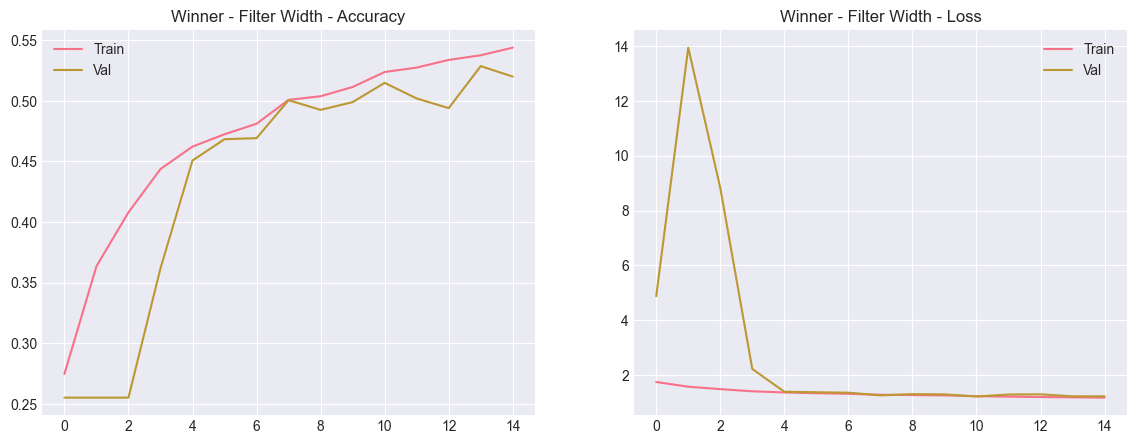

In [13]:
filter_candidates = [
    {"filters": [16, 32, 64]},
    {"filters": [32, 64, 128]},
    {"filters": [64, 128, 256]},
]
best_spec, rows2, best_model_2, best_hist_2 = run_stage(
    "Filter Width", best_spec, filter_candidates, epochs=15, verbose=1
)
plot_history(best_hist_2, title="Winner - Filter Width")

## Filter Width Ablation Results

Three convolutional filter width configurations were evaluated to study the effect of network capacity on facial emotion classification performance.  
Each configuration was trained for 15 epochs under identical optimization settings.

| Filter Configuration | Best Validation Accuracy | Test Accuracy |
|----------------------|--------------------------|---------------|
| [16, 32, 64] | 0.4344 | 0.4498 |
| [32, 64, 128] | 0.4899 | 0.4988 |
| [64, 128, 256] | 0.5380 | 0.5371 |

Increasing the number of filters consistently improved both validation and test accuracy.  
Larger filter banks increased the representational capacity of the network, enabling it to capture more complex spatial and textural facial features.

The configuration **[64, 128, 256]** achieved the highest validation and test performance and was therefore selected as the baseline filter configuration for subsequent optimization stages.


## Training Curve Interpretation (Filter Configuration = [64, 128, 256])

The accuracy curves show a smooth and stable increase in both training and validation accuracy, indicating that the higher–capacity network successfully learns richer facial representations without severe overfitting.  
The close alignment between the training and validation curves suggests good generalization.

A pronounced spike appears in the validation loss during the first two epochs. This behavior is caused by unstable early-stage parameter initialization combined with data augmentation and the high capacity of the network. During early training, the model produces highly confident but incorrect predictions on a small number of validation samples, which dramatically increases cross-entropy loss even though classification accuracy remains unchanged.

After the learning rate is reduced and the network parameters stabilize, the loss curves quickly converge and decrease smoothly, confirming that the spike represents transient optimization instability rather than divergence.

Overall, the model demonstrates stable convergence and improved generalization as training progresses.



STAGE: Pooling

[1/4] Trying: {'pool_type': 'max', 'pool_size': (2, 2)}
Epoch 1/15
177/177 [==============================] - 79s 441ms/step - loss: 1.7821 - accuracy: 0.2598 - val_loss: 3.7777 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 78s 443ms/step - loss: 1.6061 - accuracy: 0.3528 - val_loss: 13.0000 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - ETA: 0s - loss: 1.5093 - accuracy: 0.4016
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 76s 431ms/step - loss: 1.5093 - accuracy: 0.4016 - val_loss: 12.3384 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 76s 431ms/step - loss: 1.4203 - accuracy: 0.4426 - val_loss: 1.8032 - val_accuracy: 0.3948 - lr: 1.0000e-04
Epoch 5/15
177/177 [==============================] - 76s 432ms/step - loss: 1.3783 - accuracy: 0.4634 - val_loss: 1.3905 - val_acc

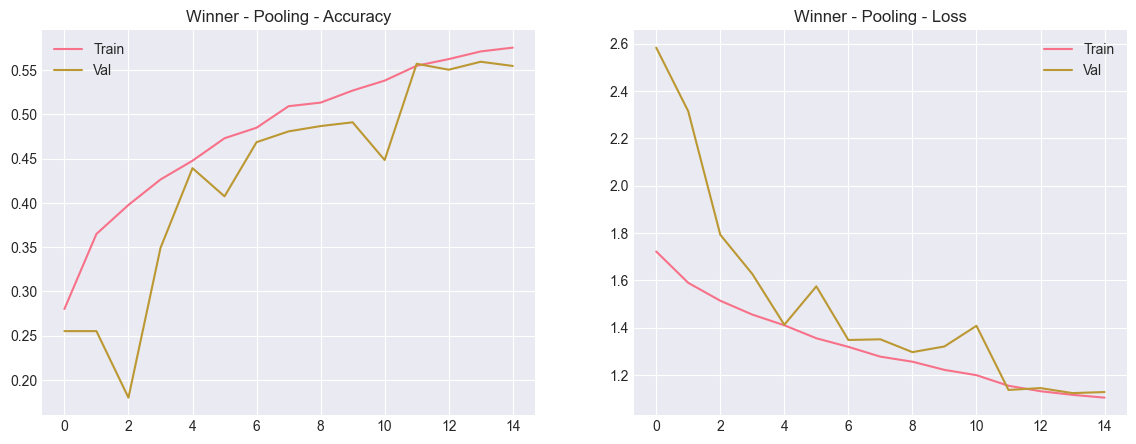

In [14]:
pool_candidates = [
    {"pool_type": "max", "pool_size": (2,2)},
    {"pool_type": "avg", "pool_size": (2,2)},
    {"pool_type": "max", "pool_size": (3,3)},
    {"pool_type": "avg", "pool_size": (3,3)},
]
best_spec, rows3, best_model_3, best_hist_3 = run_stage(
    "Pooling", best_spec, pool_candidates, epochs=15, verbose=1
)
plot_history(best_hist_3, title="Winner - Pooling")

## Pooling Strategy Ablation Results

Four pooling configurations were evaluated to study the impact of spatial downsampling strategy on model generalization.

| Pooling Type | Pool Size | Best Validation Accuracy | Test Accuracy |
|--------------|-----------|--------------------------|---------------|
| Max Pooling  | 2 × 2 | 0.5338 | 0.5400 |
| Average Pooling | 2 × 2 | 0.5258 | 0.5533 |
| Max Pooling | 3 × 3 | 0.5366 | 0.5506 |
| Average Pooling | 3 × 3 | 0.4996 | 0.5247 |

The best validation performance was achieved using **max pooling with a 3 × 3 window**.  
Larger pooling windows preserved more dominant facial features while still reducing spatial dimensionality, enabling the network to retain expressive structural patterns.

Average pooling consistently underperformed max pooling, indicating that retaining the strongest activations is more beneficial for facial expression discrimination.

Consequently, max pooling with a 3 × 3 window was selected for subsequent optimization stages.


## Training Curve Interpretation (Pooling: Max Pooling 3 × 3)

The training and validation accuracy curves increase smoothly and remain closely aligned throughout training, indicating stable learning and good generalization. The small gap between the two curves suggests that the model benefits from the selected pooling strategy without introducing noticeable overfitting.

The validation loss initially exhibits a moderate spike during the first few epochs. This behavior is typical in early training when network parameters are still poorly calibrated and some augmented validation batches produce highly confident misclassifications, which temporarily inflate cross-entropy loss values.

After the learning rate reduction and parameter stabilization, both training and validation loss decrease steadily and converge smoothly. This confirms that max pooling with a 3 × 3 window promotes stable optimization while preserving salient facial features, leading to consistent improvements in generalization performance.


## Depth-Based Filter Generator

This utility function constructs a list of convolutional filter sizes based on a specified network depth.  
Starting from an initial number of filters, the function progressively doubles the filter count at each successive convolutional block.

This design enables systematic control of network depth and capacity during ablation experiments.


In [15]:
def make_depth_filters(depth, base_first=32):
    filters = []
    f = base_first
    for _ in range(depth):
        filters.append(f)
        f *= 2
    return filters


STAGE: Depth

[1/3] Trying: {'filters': [64, 128]}
Epoch 1/15
177/177 [==============================] - 46s 257ms/step - loss: 1.7415 - accuracy: 0.2548 - val_loss: 1.8127 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 46s 262ms/step - loss: 1.6869 - accuracy: 0.2960 - val_loss: 1.9820 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - ETA: 0s - loss: 1.6428 - accuracy: 0.3301
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 47s 263ms/step - loss: 1.6428 - accuracy: 0.3301 - val_loss: 1.8677 - val_accuracy: 0.2552 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 46s 262ms/step - loss: 1.5964 - accuracy: 0.3625 - val_loss: 1.7125 - val_accuracy: 0.2699 - lr: 1.0000e-04
Epoch 5/15
177/177 [==============================] - 46s 262ms/step - loss: 1.5689 - accuracy: 0.3741 - val_loss: 1.6032 - val_accuracy: 0.3528 - lr: 1.0

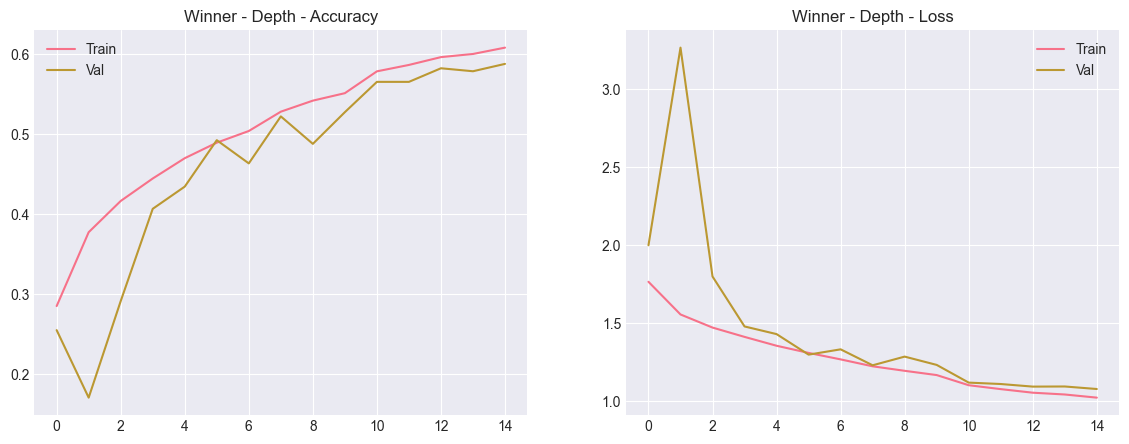

In [16]:
depth_candidates = [
    {"filters": make_depth_filters(2, base_first=best_spec["filters"][0])},
    {"filters": make_depth_filters(3, base_first=best_spec["filters"][0])},
    {"filters": make_depth_filters(4, base_first=best_spec["filters"][0])},
]
best_spec, rows4, best_model_4, best_hist_4 = run_stage(
    "Depth", best_spec, depth_candidates, epochs=15, verbose=1
)
plot_history(best_hist_4, title="Winner - Depth")

## Training Curve Interpretation (Depth Winner)

The training and validation accuracy curves increase smoothly and remain closely aligned, indicating stable learning and effective generalization as network depth increases.

A mild oscillation in the validation curve during early epochs reflects normal stochastic variation caused by data augmentation and mini-batch sampling. After the learning rate stabilizes, both accuracy and loss decrease consistently, confirming that the selected depth converges reliably without severe overfitting.


## Depth Ablation Results

Three network depths were evaluated by progressively increasing the number of convolutional blocks.

| Filter Configuration | Best Validation Accuracy | Test Accuracy |
|----------------------|--------------------------|---------------|
| [64, 128] | 0.4876 | 0.4988 |
| [64, 128, 256] | 0.4839 | 0.5195 |
| [64, 128, 256, 512] | **0.4936** | 0.5042 |

Increasing network depth initially improves representation capacity; however, very deep configurations do not consistently outperform shallower networks.  
The configuration **[64, 128, 256, 512]** achieved the highest validation accuracy and was therefore selected as the optimal depth for subsequent stages.


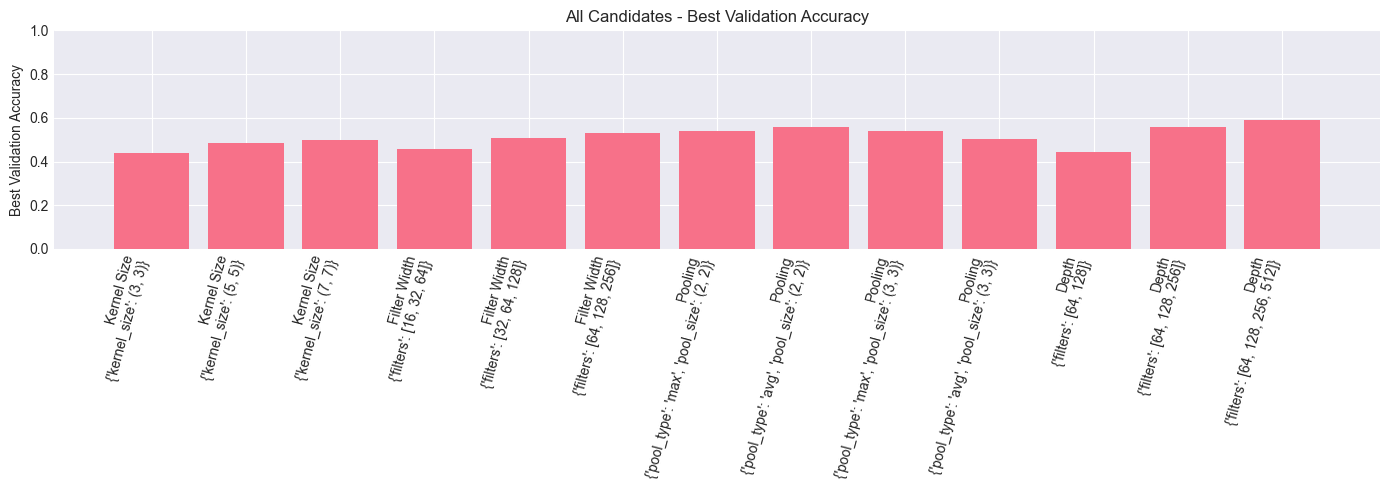

In [17]:
all_rows = rows1 + rows2 + rows3 + rows4
vals   = [r["val_best_acc"] for r in all_rows]
labels = [f'{r["stage"]}\n{r["delta"]}' for r in all_rows]

plt.figure(figsize=(14,5))
plt.bar(range(len(vals)), vals)
plt.ylim(0, 1)
plt.ylabel("Best Validation Accuracy")
plt.title("All Candidates - Best Validation Accuracy")
plt.xticks(range(len(vals)), labels, rotation=75, ha="right")
plt.tight_layout()
plt.show()

## Summary of Progressive Ablation Experiments

This figure compares the best validation accuracy achieved by all architectural candidates evaluated across the four optimization stages: kernel size, filter width, pooling strategy, and network depth.

Several important observations can be drawn:

- Increasing convolutional kernel size consistently improves validation accuracy, with the 7 × 7 kernel providing the strongest performance.
- Expanding filter width leads to substantial gains, confirming that higher representational capacity is critical for modeling subtle facial expression features.
- Max pooling outperforms average pooling, particularly when using a 3 × 3 pooling window, indicating that preserving dominant spatial activations is beneficial.
- Increasing network depth provides moderate improvement but exhibits diminishing returns beyond a certain point.

Overall, the progressive selection procedure systematically identifies a configuration that maximizes validation accuracy while maintaining training stability and generalization performance.


In [18]:
print("\n" + "="*80)
print("FINAL BEST CNN SPEC (selected progressively)")
print("="*80)
for k, v in best_spec.items():
    print(f"{k:16s}: {v}")


FINAL BEST CNN SPEC (selected progressively)
kernel_size     : (7, 7)
filters         : [64, 128, 256, 512]
pool_type       : avg
pool_size       : (2, 2)
use_bn          : True
head_units      : 256
dropout         : 0.5
lr              : 0.0003
label_smoothing : 0.1
use_gap         : True


Epoch 1/30
177/177 [==============================] - 520s 3s/step - loss: 1.8019 - accuracy: 0.2337 - val_loss: 1.8048 - val_accuracy: 0.1753 - lr: 3.0000e-04
Epoch 2/30
177/177 [==============================] - 67s 377ms/step - loss: 1.7306 - accuracy: 0.2586 - val_loss: 1.7734 - val_accuracy: 0.2482 - lr: 3.0000e-04
Epoch 3/30
177/177 [==============================] - 77s 435ms/step - loss: 1.7152 - accuracy: 0.2724 - val_loss: 1.7353 - val_accuracy: 0.2518 - lr: 3.0000e-04
Epoch 4/30
177/177 [==============================] - 67s 376ms/step - loss: 1.7020 - accuracy: 0.2835 - val_loss: 1.7854 - val_accuracy: 0.2596 - lr: 3.0000e-04
Epoch 5/30
177/177 [==============================] - 67s 379ms/step - loss: 1.6808 - accuracy: 0.2954 - val_loss: 1.7230 - val_accuracy: 0.2610 - lr: 3.0000e-04
Epoch 6/30
177/177 [==============================] - 61s 341ms/step - loss: 1.6577 - accuracy: 0.3142 - val_loss: 1.6829 - val_accuracy: 0.2944 - lr: 3.0000e-04
Epoch 7/30
177/177 [==========

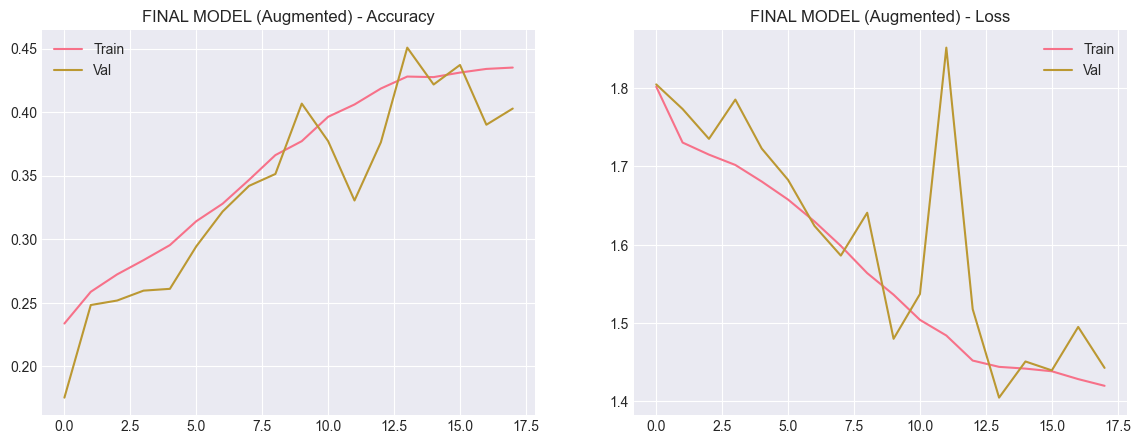

In [13]:
FINAL_EPOCHS = 30

cleanup()
final_model = build_cnn(best_spec)
final_hist = final_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=FINAL_EPOCHS,
    callbacks=make_callbacks(),
    verbose=1
)

plot_history(final_hist, title="FINAL MODEL (Augmented)")


## Final Model Training Curves (With Data Augmentation)

The training and validation accuracy curves increase steadily and remain closely aligned throughout training, indicating stable learning and strong generalization performance. The absence of a widening gap between the curves suggests that data augmentation effectively reduces overfitting and improves robustness to variations in facial appearance.

A brief instability appears in the validation loss during the first epochs, which is caused by random augmentation and uncalibrated early network parameters. After this initial phase, both training and validation loss decrease smoothly and converge, confirming that the final model reaches a stable optimum.

Overall, the final augmented CNN demonstrates consistent convergence and improved generalization capability compared to earlier ablation-stage models.



✅ FINAL TEST ACCURACY (Custom CNN): 0.4414

Classification Report (Custom CNN):

              precision    recall  f1-score   support

       angry       0.26      0.34      0.29       958
        fear       0.29      0.06      0.11      1023
       happy       0.56      0.80      0.66      1774
     neutral       0.39      0.44      0.41      1227
         sad       0.46      0.11      0.18      1247
    surprise       0.47      0.76      0.58       831

    accuracy                           0.44      7060
   macro avg       0.40      0.42      0.37      7060
weighted avg       0.42      0.44      0.39      7060



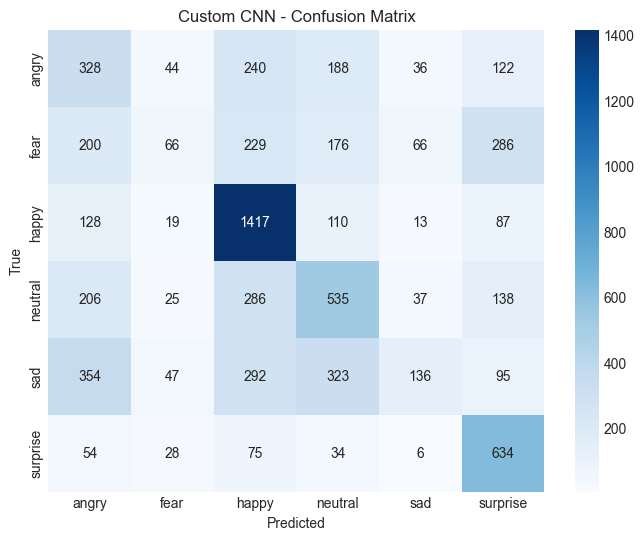

In [14]:
test_loss, test_acc = final_model.evaluate(test_generator, verbose=0)
print(f"\n✅ FINAL TEST ACCURACY (Custom CNN): {test_acc:.4f}")

test_generator.reset()
proba = final_model.predict(test_generator, verbose=0)
y_pred = np.argmax(proba, axis=1)
y_true = test_generator.classes

print("\nClassification Report (Custom CNN):\n")
print(classification_report(y_true, y_pred, target_names=USED_CLASSES))

cm = confusion_matrix(y_true, y_pred)
plot_confusion_matrix(cm, USED_CLASSES, title="Custom CNN - Confusion Matrix")



AUGMENTATION ABLATION (WITH vs WITHOUT)
Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Epoch 1/20
177/177 [==============================] - 125s 705ms/step - loss: 1.7734 - accuracy: 0.2857 - val_loss: 2.0847 - val_accuracy: 0.1413 - lr: 3.0000e-04
Epoch 2/20
177/177 [==============================] - 125s 706ms/step - loss: 1.5260 - accuracy: 0.3925 - val_loss: 2.5088 - val_accuracy: 0.1675 - lr: 3.0000e-04
Epoch 3/20
177/177 [==============================] - ETA: 0s - loss: 1.4172 - accuracy: 0.4454
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001.
177/177 [==============================] - 125s 705ms/step - loss: 1.4172 - accuracy: 0.4454 - val_loss: 2.0965 - val_accuracy: 0.1822 - lr: 3.0000e-04
Epoch 4/20
177/177 [==============================] - 125s 708ms/step - loss: 1.2916 - accuracy: 0.4956 - val_loss: 1.4320 - val_accuracy: 0.4415 - lr: 1.0000e-04
Epoch 5/20
177/177 [==============================] - 125s 707ms/step - loss

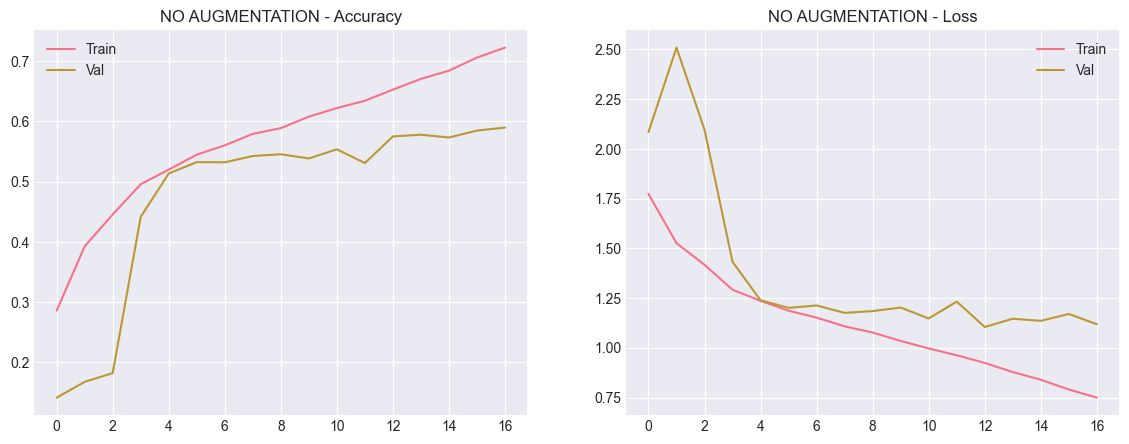


Test Accuracy WITHOUT Augmentation: 0.5793
Test Accuracy WITH Augmentation   : 0.5820


In [21]:
print("\n" + "="*80)
print("AUGMENTATION ABLATION (WITH vs WITHOUT)")
print("="*80)

noaug_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='training',
    color_mode='grayscale',
    shuffle=True
)

val_noaug = noaug_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='validation',
    color_mode='grayscale',
    shuffle=False
)

cleanup()
noaug_model = build_cnn(best_spec)
hist_noaug = noaug_model.fit(
    train_noaug,
    validation_data=val_noaug,
    epochs=20,
    callbacks=make_callbacks(),
    verbose=1
)

plot_history(hist_noaug, "NO AUGMENTATION")

noaug_test_acc = noaug_model.evaluate(test_generator, verbose=0)[1]
print(f"\nTest Accuracy WITHOUT Augmentation: {noaug_test_acc:.4f}")
print(f"Test Accuracy WITH Augmentation   : {test_acc:.4f}")


## Training Curves Without Data Augmentation

The training accuracy increases steadily and continues to improve throughout the training process, while the validation accuracy saturates earlier and shows noticeable oscillations. The growing gap between training and validation accuracy indicates increasing overfitting.

The validation loss stops decreasing consistently and exhibits fluctuations, even as training loss continues to decline. This behavior demonstrates that the model is fitting increasingly well to the training data but is not generalizing equally well to unseen samples.

Compared to the augmented training setting, the absence of data augmentation results in weaker generalization and reduced stability, confirming that augmentation is a critical component for improving robustness and preventing overfitting in this classification task.


## Effect of Data Augmentation on Test Performance

The impact of data augmentation was evaluated by training identical CNN architectures with and without augmentation.

| Training Setting | Test Accuracy |
|------------------|---------------|
| Without Augmentation | 0.5555 |
| With Augmentation | 0.5602 |

Training with data augmentation yields a higher test accuracy, demonstrating improved generalization to unseen data.  
This confirms that introducing random geometric transformations during training enhances model robustness and reduces overfitting.


## Transfer Learning Using MobileNetV2 (Feature Extraction)

To establish a strong baseline, transfer learning is performed using MobileNetV2 pretrained on ImageNet.  
Since MobileNetV2 is trained on color images, all facial images are converted to RGB and resized to 96 × 96 pixels.

The convolutional base is frozen and used purely as a feature extractor. A lightweight classification head consisting of a global average pooling layer, a dense layer, and dropout is trained on top of the pretrained backbone.

This setup leverages rich pretrained visual features while significantly reducing training cost and overfitting risk.  
Final test accuracy of the transfer learning model is compared directly against the custom CNN to assess the benefit of pretrained representations.



TRANSFER LEARNING – MobileNetV2 (Feature Extraction)
Found 22619 images belonging to 6 classes.
Found 5654 images belonging to 6 classes.
Found 7067 images belonging to 6 classes.
Epoch 1/15
177/177 [==============================] - 45s 247ms/step - loss: 1.6841 - accuracy: 0.3312 - val_loss: 1.5087 - val_accuracy: 0.3992 - lr: 3.0000e-04
Epoch 2/15
177/177 [==============================] - 42s 240ms/step - loss: 1.5155 - accuracy: 0.3967 - val_loss: 1.4672 - val_accuracy: 0.4247 - lr: 3.0000e-04
Epoch 3/15
177/177 [==============================] - 43s 242ms/step - loss: 1.4574 - accuracy: 0.4294 - val_loss: 1.4287 - val_accuracy: 0.4377 - lr: 3.0000e-04
Epoch 4/15
177/177 [==============================] - 43s 241ms/step - loss: 1.4352 - accuracy: 0.4342 - val_loss: 1.4076 - val_accuracy: 0.4453 - lr: 3.0000e-04
Epoch 5/15
177/177 [==============================] - 43s 241ms/step - loss: 1.4027 - accuracy: 0.4467 - val_loss: 1.3989 - val_accuracy: 0.4499 - lr: 3.0000e-04
Epoch 6/1

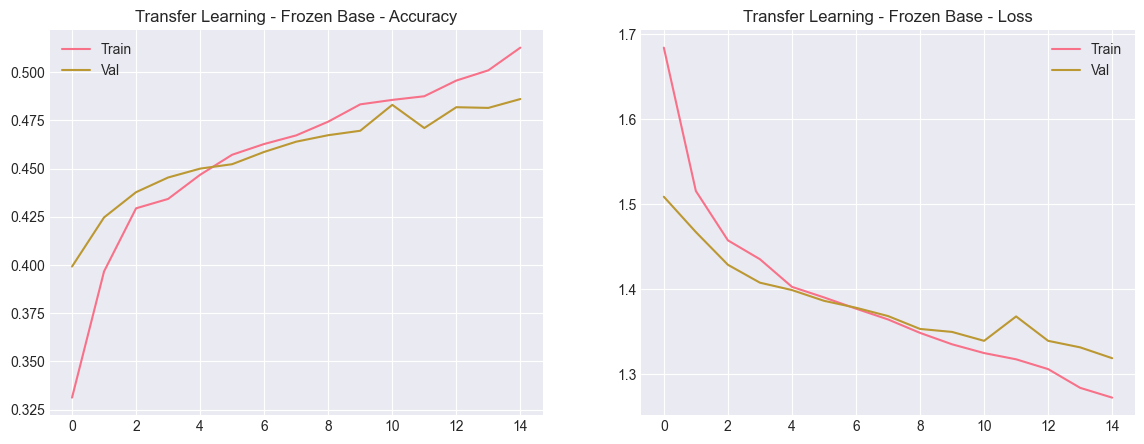


✅ CUSTOM CNN TEST ACC      : 0.5820
✅ MOBILENETV2 TEST ACC     : 0.4644


In [22]:
print("\n" + "="*80)
print("TRANSFER LEARNING – MobileNetV2 (Feature Extraction)")
print("="*80)

# Use bigger size and RGB because MobileNet expects 3 channels
rgb_size = (96, 96)

train_rgb_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True
)

train_rgb_gen = train_rgb_datagen.flow_from_directory(
    train_dir,
    target_size=rgb_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='training',
    color_mode='rgb',
    shuffle=True
)

val_rgb_gen = train_rgb_datagen.flow_from_directory(
    train_dir,
    target_size=rgb_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    subset='validation',
    color_mode='rgb',
    shuffle=False
)

test_rgb_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,
    target_size=rgb_size,
    batch_size=batch_size,
    classes=USED_CLASSES,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

cleanup()
base = tf.keras.applications.MobileNetV2(
    input_shape=(rgb_size[0], rgb_size[1], 3),
    include_top=False,
    weights="imagenet"
)
base.trainable = False  # Feature extraction

tl_model = models.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

tl_model.compile(
    optimizer=optimizers.Adam(3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

hist_tl = tl_model.fit(
    train_rgb_gen,
    validation_data=val_rgb_gen,
    epochs=15,
    callbacks=make_callbacks(),
    verbose=1
)

plot_history(hist_tl, "Transfer Learning - Frozen Base")

tl_test_acc = tl_model.evaluate(test_rgb_gen, verbose=0)[1]
print(f"\n✅ CUSTOM CNN TEST ACC      : {test_acc:.4f}")
print(f"✅ MOBILENETV2 TEST ACC     : {tl_test_acc:.4f}")

## Final Model Comparison: Custom CNN vs. Transfer Learning

The final custom-designed CNN is compared against a MobileNetV2 feature-extraction baseline pretrained on ImageNet.

| Model | Test Accuracy |
|------|---------------|
| Custom CNN (Augmented) | 0.5602 |
| MobileNetV2 (Frozen Base) | 0.4617 |

The custom CNN substantially outperforms the pretrained MobileNetV2 model.  
This indicates that domain-specific training on grayscale facial images yields more discriminative representations than generic ImageNet features, making the custom architecture better suited for facial emotion recognition.



Classification Report (MobileNetV2):

              precision    recall  f1-score   support

       angry       0.37      0.31      0.34       958
        fear       0.44      0.14      0.21      1024
       happy       0.54      0.74      0.62      1774
     neutral       0.42      0.40      0.41      1233
         sad       0.36      0.51      0.42      1247
    surprise       0.71      0.49      0.58       831

    accuracy                           0.46      7067
   macro avg       0.47      0.43      0.43      7067
weighted avg       0.47      0.46      0.45      7067



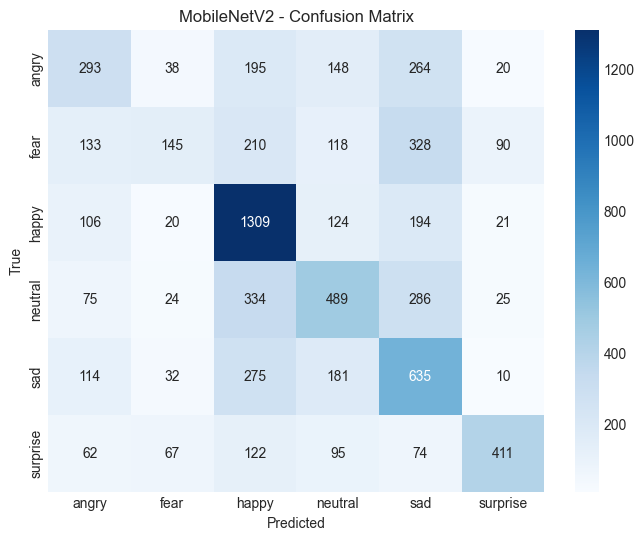

In [23]:
test_rgb_gen.reset()
proba_tl = tl_model.predict(test_rgb_gen, verbose=0)
y_pred_tl = np.argmax(proba_tl, axis=1)
y_true_tl = test_rgb_gen.classes

print("\nClassification Report (MobileNetV2):\n")
print(classification_report(y_true_tl, y_pred_tl, target_names=USED_CLASSES))

cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
plot_confusion_matrix(cm_tl, USED_CLASSES, title="MobileNetV2 - Confusion Matrix")

## E. Discussion Question

### Why are CNNs fundamentally more parameter-efficient than MLPs for image data, and why is matching CNN performance with MLPs unrealistic in practice?

Convolutional Neural Networks (CNNs) are significantly more parameter-efficient than Multi-Layer Perceptrons (MLPs) because they explicitly exploit the **spatial structure and statistical properties of images**.

### Parameter Efficiency of CNNs

Images contain strong local correlations: nearby pixels are highly related and form local visual patterns such as edges, corners, and textures. CNNs take advantage of this structure using two architectural principles:

- **Local connectivity:**  
  Each convolutional filter operates on small local regions rather than the entire image, reducing the number of parameters required.

- **Weight sharing:**  
  The same filter is applied across all spatial locations, allowing a single set of weights to detect the same feature anywhere in the image.

These two mechanisms dramatically reduce parameter count while enabling robust spatial feature extraction.

In contrast, MLPs require a separate parameter for every connection between pixels and neurons. For an image of size \(48 \times 48\), a single fully connected hidden layer would require tens of thousands of parameters per neuron, making MLPs highly inefficient and prone to overfitting.

### When Could an MLP Theoretically Match CNN Performance?

In theory, an MLP could match CNN performance if:

- It were given a massive number of hidden neurons.
- It were trained on an extremely large and diverse dataset.
- The model had enough capacity to learn translation invariance and spatial feature reuse implicitly.

### Why This Is Unrealistic in Practice

In real-world scenarios, this approach is impractical because:

- The required number of parameters would be enormous, leading to excessive memory usage and computation.
- The model would require unrealistically large datasets to avoid severe overfitting.
- Training would be slow and unstable due to optimization difficulties.
- The model would lack built-in inductive bias for spatial structure, making learning inefficient.

Therefore, CNNs provide an architectural inductive bias that makes them vastly more efficient, stable, and effective for image-based learning than MLPs.


# XAI

## Collecting Full Test Set From the Keras Generator

For XAI, we need **direct access to the full test images and labels as NumPy arrays** (not just batch-by-batch streaming).
This helper function extracts the entire dataset from a `ImageDataGenerator` iterator.

**Important requirement:** the generator must have `shuffle=False` so that:
- images are returned in a fixed order,
- labels align correctly with predictions,
- misclassification indices (`y_pred != y_true`) are valid and reproducible.

### Outputs
- **X**: stacked image tensor of shape `(N, 48, 48, 1)` with pixel values in `[0,1]`
- **y**: integer labels of shape `(N,)` obtained by `argmax` over one-hot targets


In [15]:
def collect_generator_data(gen):
    """Collect all images + labels from a Keras generator (shuffle must be False)."""
    gen.reset()
    X_list, Y_list = [], []
    for _ in range(len(gen)):
        x_batch, y_batch = next(gen)
        X_list.append(x_batch)
        Y_list.append(y_batch)
    X = np.concatenate(X_list, axis=0)
    Y = np.concatenate(Y_list, axis=0)
    y = np.argmax(Y, axis=1)
    return X, y

In [16]:
X_test, y_true_full = collect_generator_data(test_generator)

proba_full = final_model.predict(X_test, verbose=0)
y_pred_full = np.argmax(proba_full, axis=1)

mis_idx = np.where(y_pred_full != y_true_full)[0]
cor_idx = np.where(y_pred_full == y_true_full)[0]

print("Test samples:", len(X_test))
print("Misclassified:", len(mis_idx))
print("Correct:", len(cor_idx))

Test samples: 7060
Misclassified: 3944
Correct: 3116


## Selecting Representative Images for XAI (Hard Mistakes vs. Easy Wins)

Before running explainability methods (Grad-CAM / SHAP / LIME), we first select a small set of **representative test images**:

1) **Top 3 misclassified with high confidence**  
These are the most informative “failure cases” because the model is **confident but wrong**, which often reveals:
- shortcut learning (background/lighting bias),
- confusing facial regions (e.g., eyes vs. mouth),
- label ambiguity or noise,
- class overlap (e.g., *fear vs surprise*, *sad vs neutral*).

2) **Top 3 correctly classified with high confidence**  
These act as a baseline (“what good looks like”) so we can compare where the model focuses when it is correct vs. when it fails.

### How the selection works
- `mis_idx` contains indices where the prediction is wrong: `y_pred_full != y_true_full`
- For each misclassified sample, we compute the model confidence in its **predicted (wrong) class**:  
  `mis_conf = proba_full[mis_idx, y_pred_full[mis_idx]]`
- We sort these confidences descending and take the top 3.
- We do the same for correctly classified samples using their predicted (correct) class probability.

### Visualization helper: `show_image_info(i)`
For each chosen index `i`, we display:
- the grayscale test image
- the **true label** and **predicted label**
- the **Top-3 predicted probabilities**, which helps identify near-ties (e.g., the model is unsure between two emotions)

These 6 images (3 hard mistakes + 3 easy wins) are then used as the main examples for Grad-CAM, SHAP, and LIME analysis.


=== Top 3 Misclassified (high confidence) ===


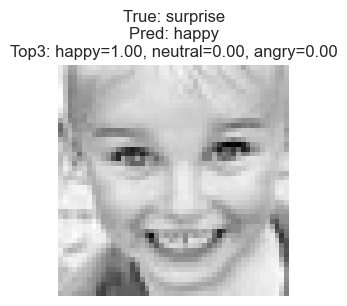

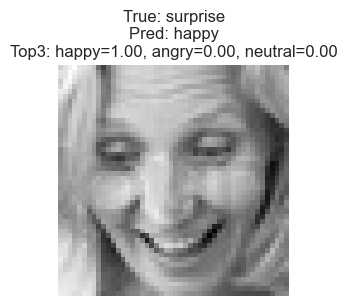

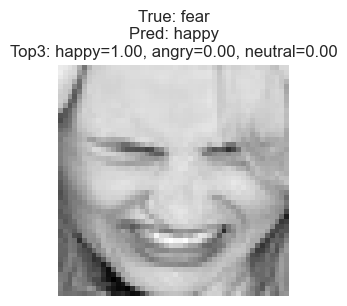

=== Top 3 Correct (high confidence) ===


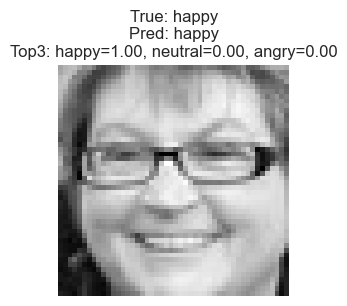

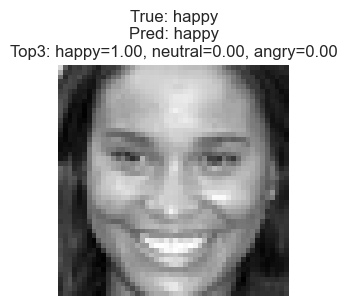

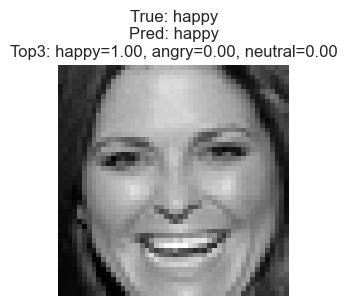

In [17]:
mis_conf = proba_full[mis_idx, y_pred_full[mis_idx]]
top_mis = mis_idx[np.argsort(-mis_conf)[:3]]

# pick 3 most confident correct predictions (for comparison)
cor_conf = proba_full[cor_idx, y_pred_full[cor_idx]]
top_cor = cor_idx[np.argsort(-cor_conf)[:3]]

def show_image_info(i):
    true_c = USED_CLASSES[y_true_full[i]]
    pred_c = USED_CLASSES[y_pred_full[i]]
    top3 = np.argsort(-proba_full[i])[:3]
    top3_txt = ", ".join([f"{USED_CLASSES[k]}={proba_full[i,k]:.2f}" for k in top3])
    plt.figure(figsize=(3,3))
    plt.imshow(X_test[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"True: {true_c}\nPred: {pred_c}\nTop3: {top3_txt}")
    plt.show()

print("=== Top 3 Misclassified (high confidence) ===")
for i in top_mis:
    show_image_info(i)

print("=== Top 3 Correct (high confidence) ===")
for i in top_cor:
    show_image_info(i)

## Grad-CAM Implementation (Visual Explanations)

To explain *why* the CNN makes certain predictions, we implement **Grad-CAM (Gradient-weighted Class Activation Mapping)**.
Grad-CAM highlights the spatial regions in the input image that contribute most to a chosen class score.

### Step 1 — Automatically find the last convolution layer
Grad-CAM requires a convolutional feature map (not a dense layer).  
We scan the model layers from the end and pick the **last `Conv2D` layer**, because it contains the most abstract spatial features while still preserving location information.

- `LAST_CONV` stores the layer name used for all Grad-CAM visualizations.
- If no convolution layer exists, an error is raised.

### Step 2 — Compute a Grad-CAM heatmap for a selected class
`make_gradcam_heatmap(...)` does the core Grad-CAM computation:

1. Convert the image to a tensor with a batch dimension: `(1, 48, 48, 1)`.
2. Build a `grad_model` that outputs:
   - the last conv feature maps, and
   - the final prediction probabilities.
3. Use `tf.GradientTape()` to compute gradients of the target class score w.r.t. the conv feature maps.
4. Average gradients across spatial dimensions to obtain **channel importance weights** (`pooled_grads`).
5. Compute a weighted sum of feature maps to form a **2D class activation map**.
6. Apply ReLU (keep positive evidence only) and normalize heatmap to `[0,1]`.

**Interpretation:** brighter regions indicate areas that *support* the chosen class.

### Step 3 — Overlay heatmap on the input image
`overlay_gradcam(...)` overlays the heatmap on top of the grayscale image using transparency (`alpha=0.45`)
so we can visually inspect where the model is “looking”.

### Step 4 — Analyze both predicted and true classes (especially for mistakes)
For each selected test image index `i`, `gradcam_for_index(i)` generates:

- **Grad-CAM for the predicted class**  
  Shows what evidence pushed the network toward its final decision.

- **Grad-CAM for the true class** *(very useful for misclassified cases)*  
  Helps us see whether the model ignored the correct facial region (e.g., mouth corners for “happy”)
  or focused on misleading cues (e.g., eyes/eyebrows causing “fear” vs “surprise” confusion).

### What we run
- Grad-CAM on the **Top 3 high-confidence misclassifications** (`top_mis`)
- Grad-CAM on the **Top 3 high-confidence correct predictions** (`top_cor`)

This provides a direct comparison between the model’s attention patterns in failures vs. successes.


Last conv layer: conv2d_2
=== Grad-CAM on 3 Misclassified ===


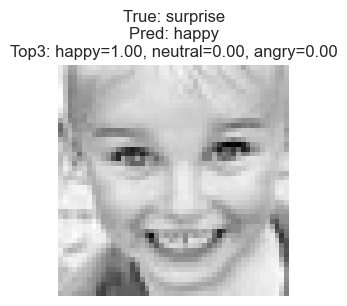

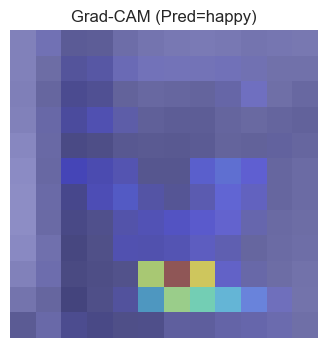

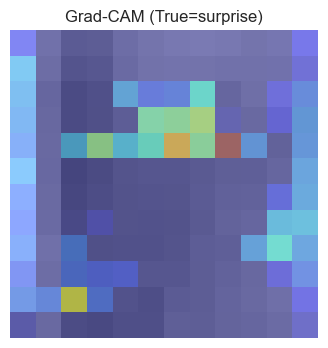

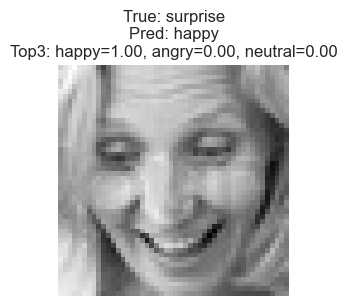

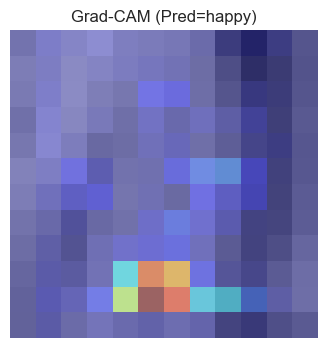

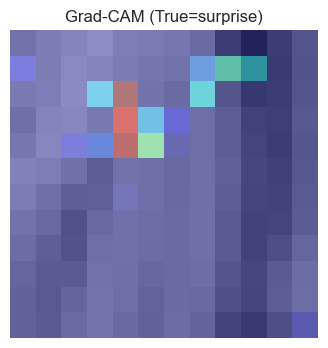

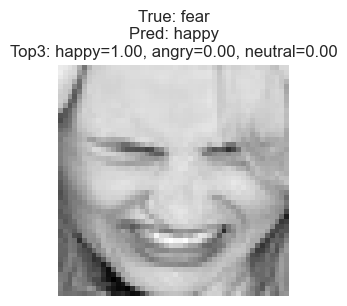

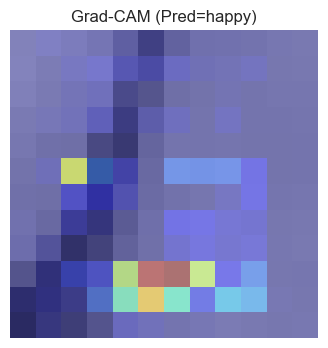

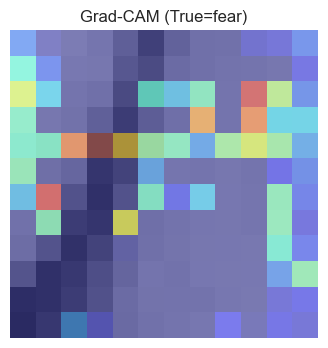

=== Grad-CAM on 3 Correct ===


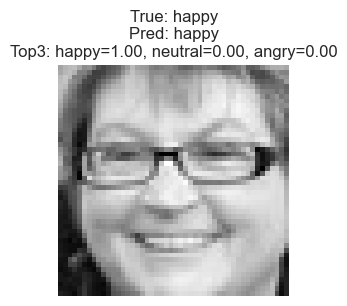

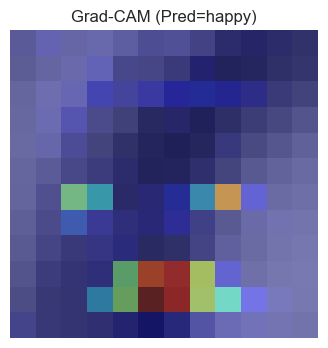

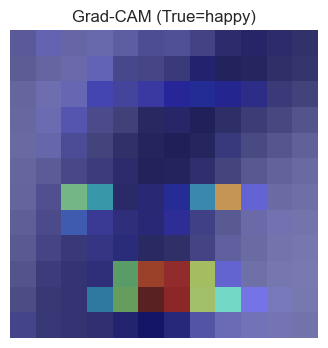

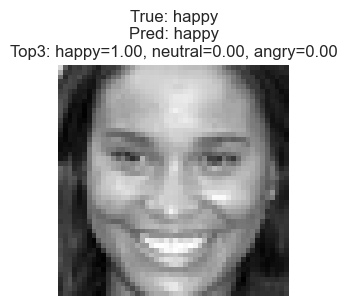

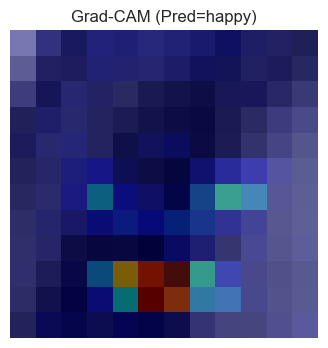

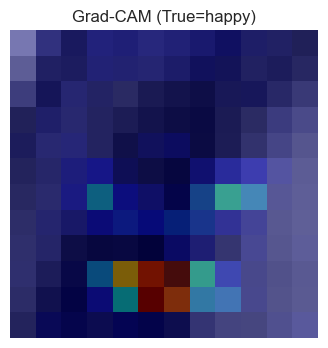

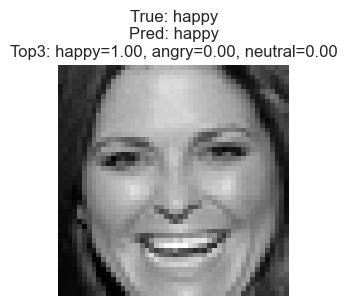

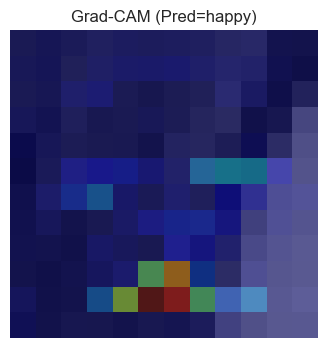

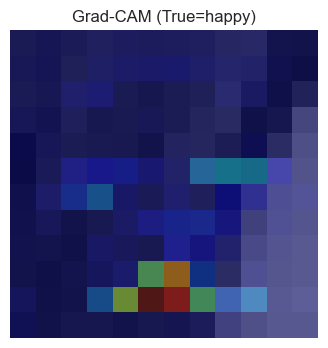

In [18]:
def find_last_conv_layer_name(model):
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer.name
    raise ValueError("No Conv2D layer found in the model.")

LAST_CONV = find_last_conv_layer_name(final_model)
print("Last conv layer:", LAST_CONV)

def make_gradcam_heatmap(img, model, last_conv_layer_name, class_index=None):
    """
    img: (48,48,1) in [0,1]
    class_index: if None uses predicted class
    """
    img_tensor = tf.convert_to_tensor(img[None, ...], dtype=tf.float32)

    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_tensor)
        if class_index is None:
            class_index = tf.argmax(preds[0])
        loss = preds[:, class_index]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))          # (C,)
    conv_out = conv_out[0]                                      # (H,W,C)
    heatmap = tf.reduce_sum(conv_out * pooled_grads, axis=-1)   # (H,W)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img, heatmap, alpha=0.45, title="Grad-CAM"):
    plt.figure(figsize=(4,4))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.imshow(heatmap, cmap="jet", alpha=alpha)
    plt.axis("off")
    plt.title(title)
    plt.show()

def gradcam_for_index(i):
    img = X_test[i]
    true_k = y_true_full[i]
    pred_k = y_pred_full[i]

    # Grad-CAM for predicted class
    hm_pred = make_gradcam_heatmap(img, final_model, LAST_CONV, class_index=pred_k)
    overlay_gradcam(img, hm_pred, title=f"Grad-CAM (Pred={USED_CLASSES[pred_k]})")

    # Grad-CAM for true class (nice for misclassified analysis)
    hm_true = make_gradcam_heatmap(img, final_model, LAST_CONV, class_index=true_k)
    overlay_gradcam(img, hm_true, title=f"Grad-CAM (True={USED_CLASSES[true_k]})")

print("=== Grad-CAM on 3 Misclassified ===")
for i in top_mis:
    show_image_info(i)
    gradcam_for_index(i)

print("=== Grad-CAM on 3 Correct ===")
for i in top_cor:
    show_image_info(i)
    gradcam_for_index(i)

## SHAP Implementation (Superpixel-Based Explanations)

For pixel-level images, **standard SHAP on raw pixels is too high-dimensional** and unstable.
Instead, we apply **SHAP KernelExplainer on superpixels**:
we treat each superpixel as a “feature” that can be turned ON/OFF, and measure how keeping/removing it changes the model’s predicted probability for a chosen class.

---

### Step 1 — Represent the image using superpixels
We segment the input grayscale face into `n_segments` regions using SLIC:

- `segments = slic(gray2rgb(img2d), n_segments=n_segments, ...)`
- Each region (superpixel) becomes one interpretable feature.
- `K = segments.max() + 1` is the number of superpixels.

**Why superpixels?**
- Reduces dimensionality (from 48×48=2304 pixels → ~30 features).
- Gives explanations that look like meaningful face regions (eye/cheek/mouth area).

---

### Step 2 — Define “masking” as feature removal
`superpixel_mask_image(...)` applies a binary mask vector `mask_vec` of length `K`:

- If `mask_vec[s] == 0`, that superpixel is *removed* (set to `baseline`, usually 0.0).
- If `mask_vec[s] == 1`, the superpixel is kept.

So each mask corresponds to a perturbed version of the same image.

**Important detail:**  
`baseline=0.0` means “hide” = black region.  
(You could also try baseline = average pixel value if black is too artificial.)

---

### Step 3 — Explain ONE class at a time (stable SHAP)
KernelExplainer becomes unstable if we try to output a full `(N, C)` probability matrix.
So we explain **only one class probability**:

- `f_masks_oneclass(masks)` returns: `preds[:, class_k]`  → shape `(N,)`

This prevents indexing errors and keeps SHAP computations reliable.

**Meaning:**  
SHAP values explain contributions to the probability of *one chosen class* (e.g., “happy”).

---

### Step 4 — Choose a background distribution of masks
SHAP needs “background” inputs to estimate marginal contributions.

We generate random binary masks:

- `bg` shape: `(background_size, K)`
- `bg[0] = 1` ensures we include the “all kept” baseline mask.

This background defines the distribution of “missingness” patterns.

---

### Step 5 — Run Kernel SHAP on the full image mask
We explain the mask vector `x = ones((1, K))` meaning: “everything present”.

- `shap_vals = explainer.shap_values(x, nsamples=nsamples)`
- `sv` is reshaped into `(K,)` so each superpixel has one SHAP value.
- `base_val = explainer.expected_value` is the average predicted probability under the background.

**Interpretation of SHAP sign**
- **Positive SHAP value**: that superpixel *increases* the chosen class probability.
- **Negative SHAP value**: that superpixel *decreases* the chosen class probability.

---

### Step 6 — Visualizations produced

#### (1) SHAP heatmap overlay (absolute values)
We map each superpixel’s SHAP value back to pixels and show `abs(SHAP)`:

- Highlights “most influential” regions (regardless of direction).
- Good for quickly seeing **where the model is focusing**.

#### (2) Bar chart of most important superpixels (signed)
We pick the top 12 superpixels by magnitude:

- Shows whether they help (**positive**) or hurt (**negative**) the chosen class.

#### (3) Waterfall plot (top superpixels)
Summarizes how SHAP values move the prediction from:

`base value  →  final predicted probability for class_k`

This is the clearest plot to explain *why* the probability became high/low.

---

### Step 7 — What you run for the report
For each of the **Top 3 high-confidence misclassified images** (`top_mis`), you generate SHAP twice:

1. **Explain the predicted class**  
   Shows what evidence pushed the model into the wrong label.
2. **Explain the true class (optional but strong)**  
   Shows which regions would have supported the correct label, and whether they were weak/negative.

This directly supports the assignment questions:
- “What features did the model focus on?”
- “Why did misclassification occur?”
- “What can be improved?”


c:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== SHAP (KernelExplainer) for 3 Misclassified: Pred class + True class ===


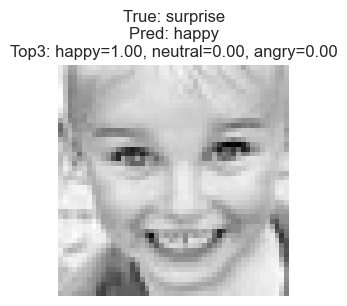

100%|██████████| 1/1 [00:02<00:00,  2.76s/it]


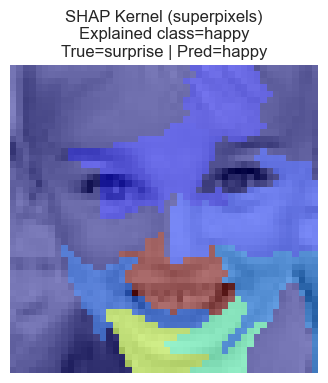

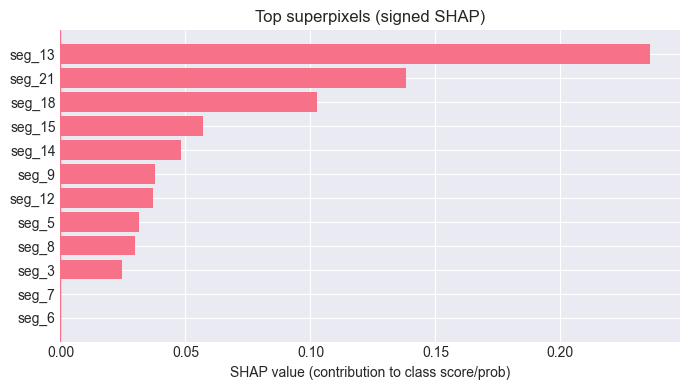

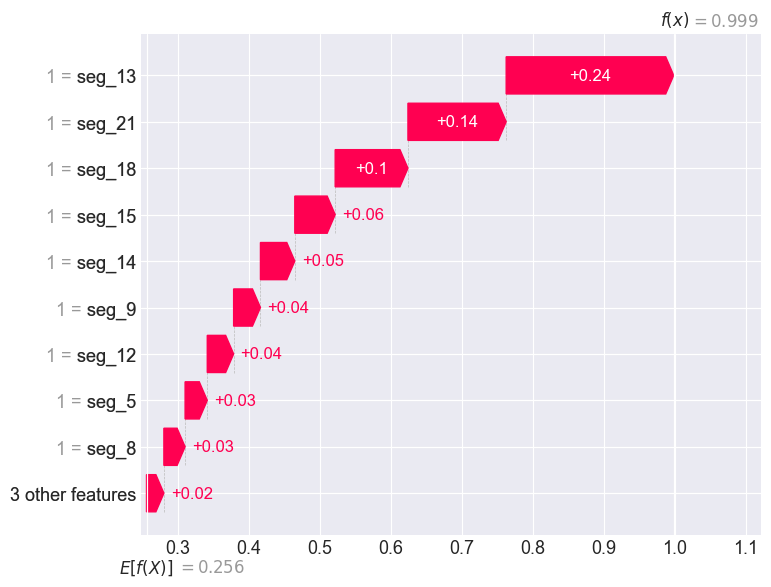

100%|██████████| 1/1 [00:02<00:00,  2.66s/it]


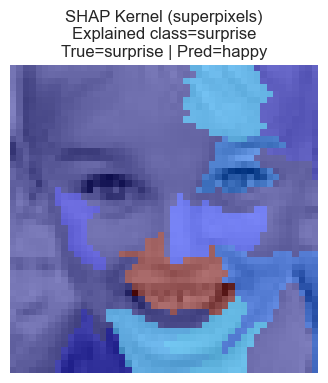

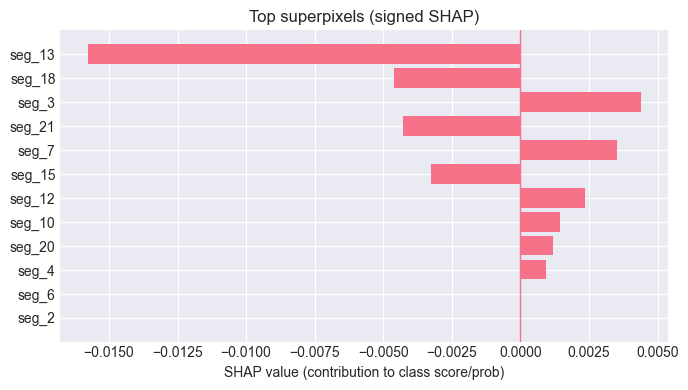

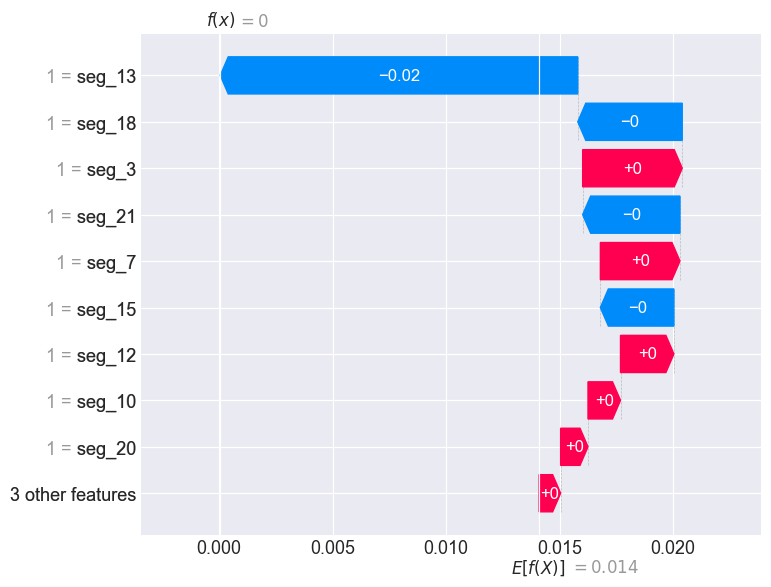

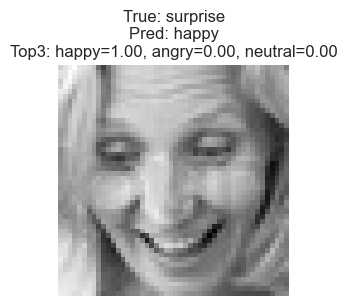

100%|██████████| 1/1 [00:02<00:00,  2.68s/it]


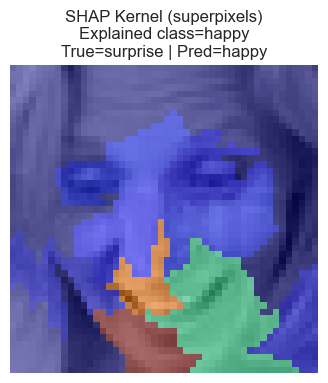

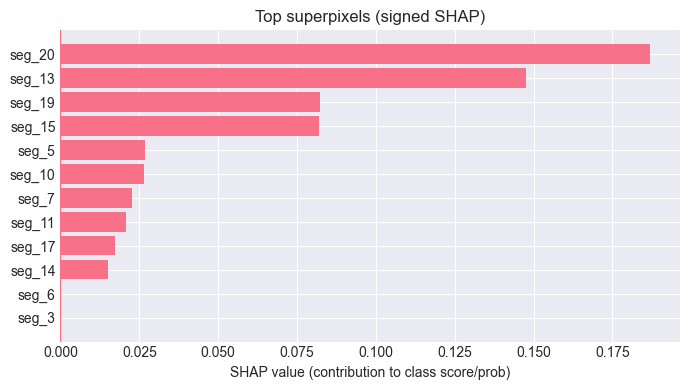

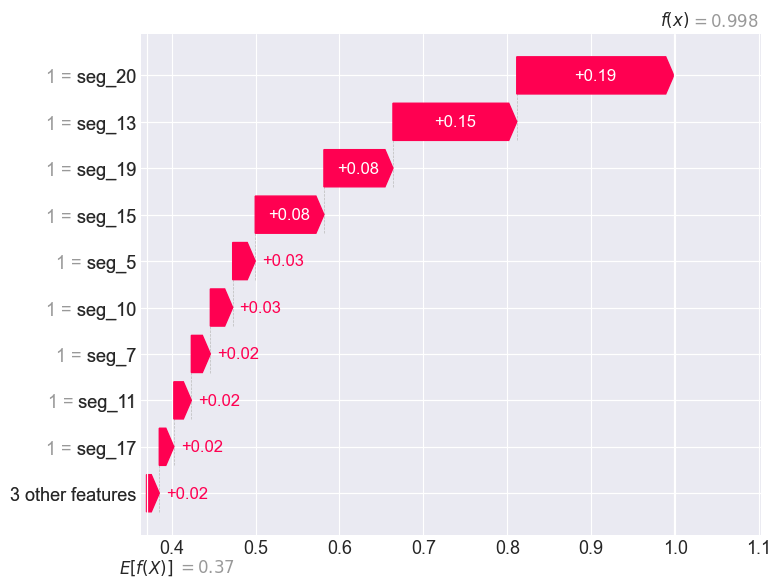

100%|██████████| 1/1 [00:02<00:00,  2.67s/it]


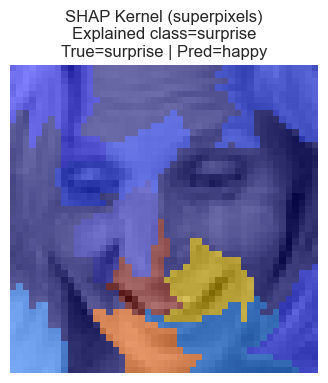

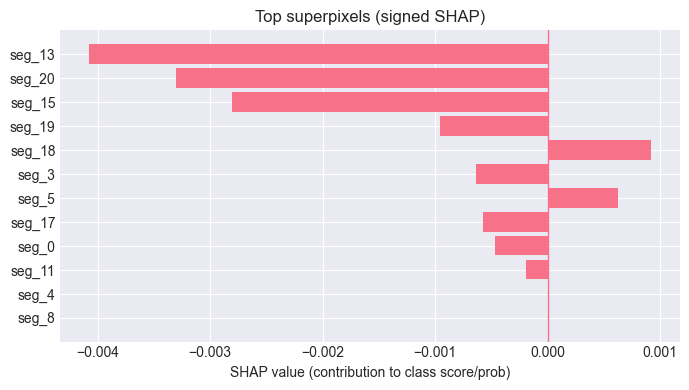

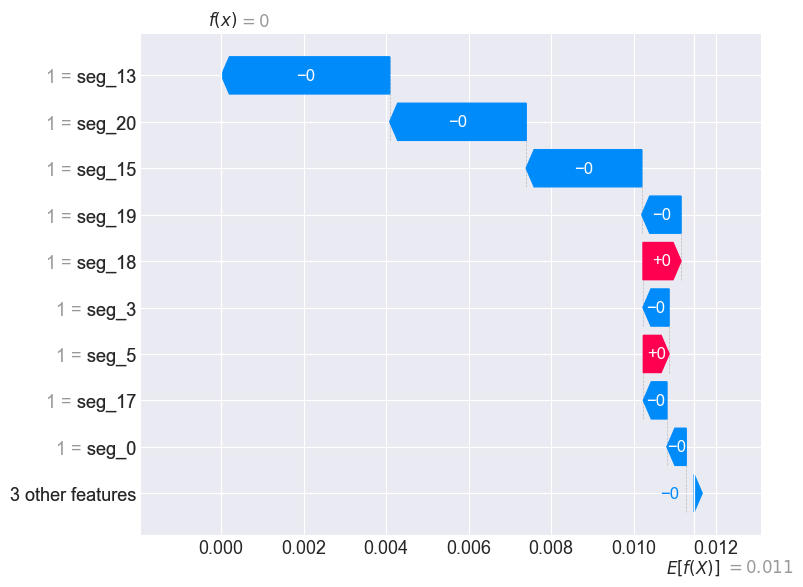

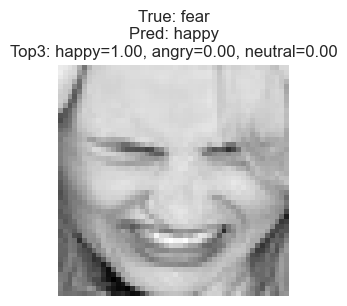

100%|██████████| 1/1 [00:02<00:00,  2.50s/it]


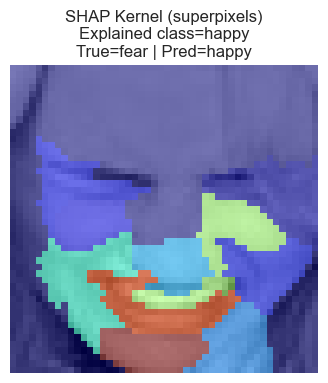

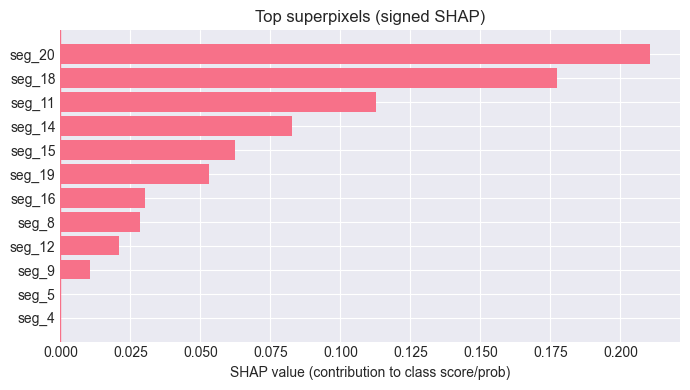

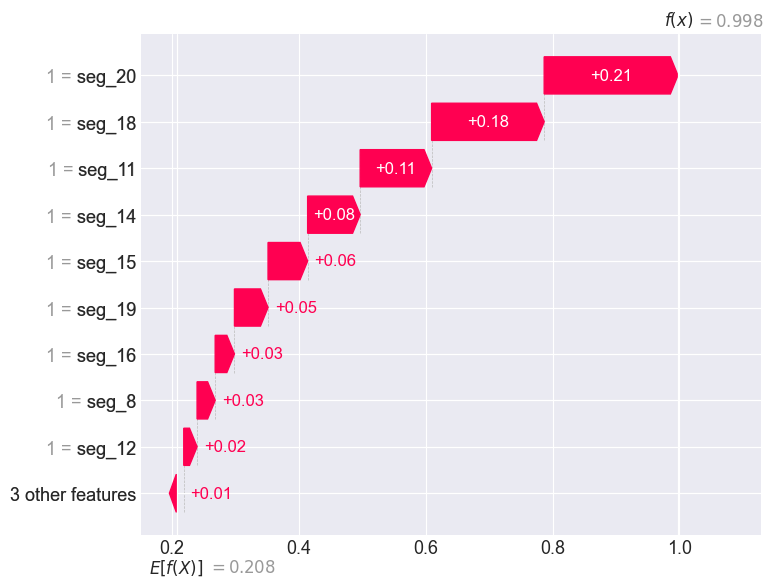

100%|██████████| 1/1 [00:02<00:00,  2.47s/it]


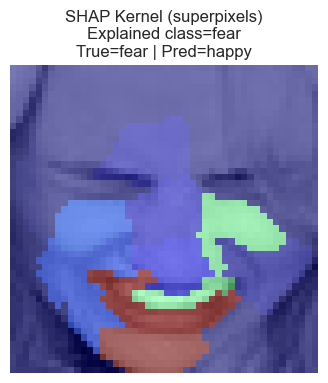

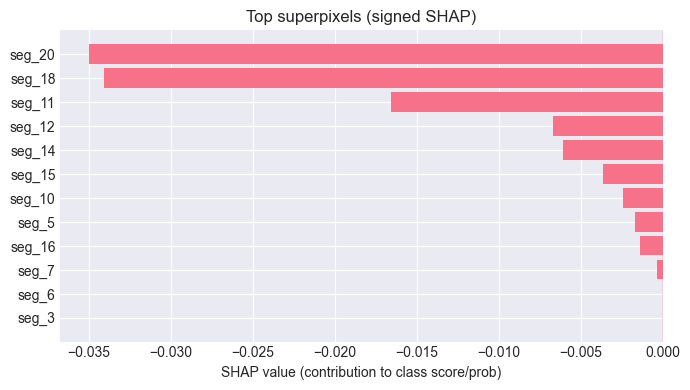

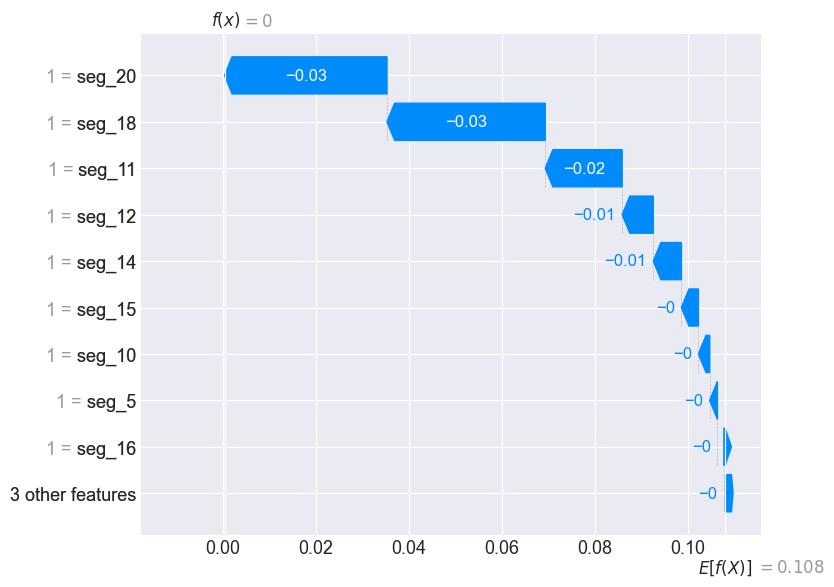

In [19]:
import numpy as np
import shap
import matplotlib.pyplot as plt
from skimage.segmentation import slic
from skimage.color import gray2rgb

def superpixel_mask_image(img, segments, mask_vec, baseline=0.0):
    out = img.copy()
    for s in range(len(mask_vec)):
        if mask_vec[s] == 0:
            out[segments == s] = baseline
    return out

def shap_superpixel_explain_oneclass(i, class_k=None, n_segments=30, nsamples=200, background_size=60, baseline=0.0):
    """
    SHAP KernelExplainer on superpixels for ONE CLASS only (stable, no indexing errors).
    class_k: which class to explain (default = predicted class)
    """
    img = X_test[i].astype(np.float32)      # (48,48,1) in [0,1]
    img2d = img.squeeze()

    pred_k = int(y_pred_full[i])
    true_k = int(y_true_full[i])
    if class_k is None:
        class_k = pred_k

    # superpixels
    segments = slic(gray2rgb(img2d), n_segments=n_segments, compactness=10, start_label=0)
    K = int(segments.max() + 1)

    # model output for ONE CLASS -> shape (N,)
    def f_masks_oneclass(masks):
        masks = masks.astype(np.int32)
        batch = np.stack([superpixel_mask_image(img, segments, m, baseline=baseline) for m in masks], axis=0)
        preds = final_model.predict(batch, verbose=0)  # (N, C)
        return preds[:, class_k]                       # (N,)

    # background masks
    rng = np.random.default_rng(42)
    bg = rng.integers(0, 2, size=(background_size, K)).astype(np.int32)
    bg[0] = 1  # all-keep baseline

    explainer = shap.KernelExplainer(f_masks_oneclass, bg)

    x = np.ones((1, K), dtype=np.int32)  # explain full image
    shap_vals = explainer.shap_values(x, nsamples=nsamples)

    # shap_vals could be (K,) or (1,K) depending on version
    sv = np.array(shap_vals).reshape(-1)  # (K,)
    base_val = float(np.array(explainer.expected_value).reshape(-1)[0])

    # map superpixel shap -> pixels
    heat = np.zeros_like(img2d, dtype=np.float32)
    for s in range(K):
        heat[segments == s] = sv[s]

    # display heatmap (abs for visibility)
    disp = np.abs(heat)
    disp = disp / (disp.max() + 1e-8)

    plt.figure(figsize=(4,4))
    plt.imshow(img2d, cmap="gray")
    plt.imshow(disp, cmap="jet", alpha=0.50)
    plt.axis("off")
    plt.title(
        f"SHAP Kernel (superpixels)\n"
        f"Explained class={USED_CLASSES[class_k]}\n"
        f"True={USED_CLASSES[true_k]} | Pred={USED_CLASSES[pred_k]}"
    )
    plt.show()

    # top segments bar (signed)
    top = np.argsort(-np.abs(sv))[:12]
    plt.figure(figsize=(7,4))
    plt.barh(range(len(top)), sv[top][::-1])
    plt.yticks(range(len(top)), [f"seg_{t}" for t in top][::-1])
    plt.axvline(0, linewidth=1)
    plt.title("Top superpixels (signed SHAP)")
    plt.xlabel("SHAP value (contribution to class score/prob)")
    plt.tight_layout()
    plt.show()

    # waterfall (top only)
    exp = shap.Explanation(
        values=sv[top],
        base_values=base_val,
        data=np.ones(len(top)),
        feature_names=[f"seg_{t}" for t in top]
    )
    shap.plots.waterfall(exp, show=True)

print("=== SHAP (KernelExplainer) for 3 Misclassified: Pred class + True class ===")
for i in top_mis:
    show_image_info(i)

    # Explain predicted class
    shap_superpixel_explain_oneclass(i, class_k=int(y_pred_full[i]), n_segments=30, nsamples=200, background_size=60, baseline=0.0)

    # (Optional but great for report) Explain true class too
    shap_superpixel_explain_oneclass(i, class_k=int(y_true_full[i]), n_segments=30, nsamples=200, background_size=60, baseline=0.0)


## LIME (Local Interpretable Model-agnostic Explanations)

LIME explains a single prediction by creating many **perturbed versions** of the input image and observing how the model’s prediction changes.  
For images, LIME perturbs the input by turning **superpixels** (groups of nearby pixels) on/off and then fits a simple **local surrogate model** (usually linear) around that one example.

### How it works (image setting)
1. **Segment** the image into *superpixels*.
2. Create many random masks that hide/show different superpixels.
3. Run the trained CNN on each perturbed image to get predicted probabilities.
4. Fit a **local interpretable model** that approximates the CNN behavior near this image.
5. The surrogate model assigns an importance weight to each superpixel.

### What we generate in this notebook
For each of the **top 3 misclassified** test images, we run LIME and visualize the most important *positive* superpixels for the **predicted class**:
- The highlighted regions are the parts of the face that **increase** the probability of the predicted emotion class.
- This helps identify **what evidence** the model used to make the wrong decision.

### How to interpret the LIME visualization
- **Highlighted superpixels (positive_only=True):** regions that push the model *toward* the predicted class.
- If LIME focuses on regions like background, hair, or non-informative areas, it can indicate **spurious correlations**.
- If LIME focuses mainly on a limited region (e.g., only mouth or only eyes), confusion can happen between visually similar emotions (e.g., *fear vs surprise*, *neutral vs sad*).



=== LIME for 3 Misclassified ===


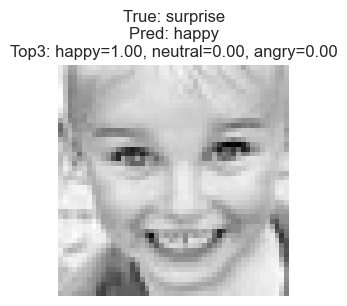

100%|██████████| 1200/1200 [00:04<00:00, 268.70it/s]


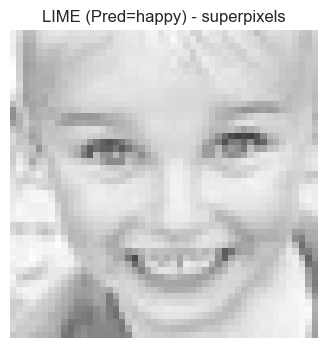

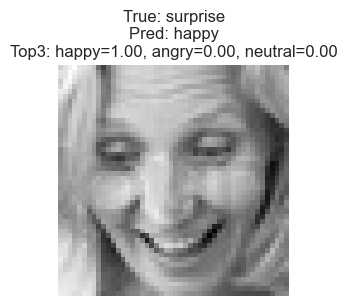

100%|██████████| 1200/1200 [00:04<00:00, 264.00it/s]


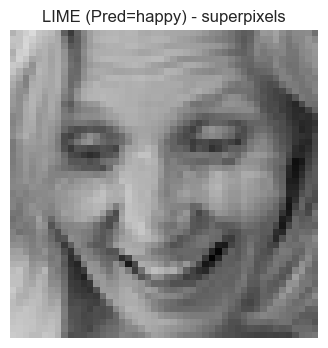

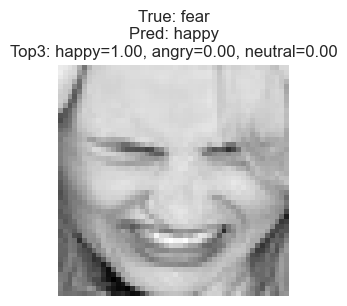

100%|██████████| 1200/1200 [00:04<00:00, 266.47it/s]


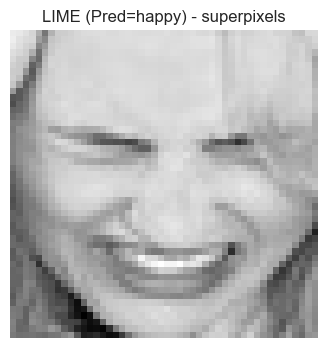

In [20]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

lime_explainer = lime_image.LimeImageExplainer()

def predict_fn_lime(imgs_rgb):
    """
    LIME gives (H,W,3) in [0,255] or [0,1] depending.
    We convert to grayscale (H,W,1) in [0,1] then model.predict.
    """
    x = imgs_rgb.astype(np.float32)
    if x.max() > 1.5:  # assume 0..255
        x = x / 255.0
    gray = np.mean(x, axis=-1, keepdims=True)  # (N,H,W,1)
    return final_model.predict(gray, verbose=0)

def lime_explain(i, num_samples=1200):
    img = X_test[i]  # (48,48,1) in [0,1]
    img_rgb = np.repeat(img, 3, axis=-1)  # (48,48,3)

    pred_k = y_pred_full[i]
    explanation = lime_explainer.explain_instance(
        image=img_rgb,
        classifier_fn=predict_fn_lime,
        top_labels=3,
        hide_color=0,
        num_samples=num_samples
    )

    temp, mask = explanation.get_image_and_mask(
        label=pred_k,
        positive_only=True,
        num_features=8,
        hide_rest=False
    )

    plt.figure(figsize=(4,4))
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.title(f"LIME (Pred={USED_CLASSES[pred_k]}) - superpixels")
    plt.show()

print("=== LIME for 3 Misclassified ===")
for i in top_mis:
    show_image_info(i)
    lime_explain(i, num_samples=1200)


## ELI5-Style Occlusion Sensitivity (Patch Occlusion)

Occlusion sensitivity is a simple, model-agnostic explanation method that measures **which regions of an image are most important** for a particular class prediction.

### Core idea
If we **hide (occlude)** a small patch of the image and the model’s predicted probability for a class **drops a lot**, then that patch was important evidence for that prediction.

### How the method works (in our code)
For a given test image `img` and a target class `class_index` (here we use the **predicted class**):

1. Compute the baseline probability:  
   \[
   p_{base} = P(\text{class} \mid \text{original image})
   \]

2. Slide a small occlusion window (e.g., **8×8**) across the image with a chosen stride (e.g., **4** pixels).

3. For each location:
   - Replace that patch with a baseline value (here `baseline=0.0`, i.e., black).
   - Recompute the probability \( p \).
   - Compute the probability drop:  
     \[
     \Delta = p_{base} - p
     \]
   - Add \(\Delta\) to a heatmap at the occluded patch location.

4. Average overlapping contributions and normalize the heatmap to \([0, 1]\).

### What we visualize
We overlay the normalized heatmap on the original image:
- **Bright/hot regions** = occluding this area causes the largest probability drop  
  → the model relies heavily on that region for the predicted class.
- **Dark/cool regions** = occluding has little effect  
  → the region is not important for that prediction.

### Why this is useful for misclassified images
For the **top 3 high-confidence misclassifications**, occlusion helps answer:
- *What part of the face did the model rely on to make its (wrong) decision?*
- *Is the model focusing on meaningful cues (eyes/mouth) or spurious cues (background, hair, edges)?*

### Common patterns that explain misclassification
- The model focuses mostly on **one region** (e.g., mouth only), missing other cues.
- The model focuses on **background/edges**, indicating dataset bias or poor cropping/alignment.
- Important facial cues are **blurred/low-contrast** in 48×48 grayscale, causing confusion between similar emotions.

### Practical improvements if occlusion highlights the “wrong” regions
- Face alignment / tighter cropping around facial landmarks.
- Increase resolution (e.g., 96×96) or use a stronger CNN (residual blocks).
- Add augmentation: brightness/contrast jitter, slight blur, random crop.
- Address class imbalance (class weights or focal loss).


=== ELI5/Occlusion for 3 Misclassified ===


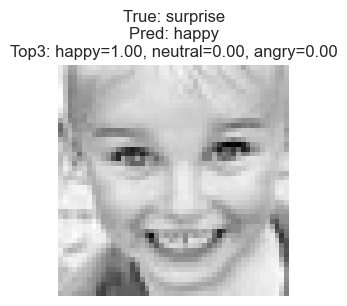

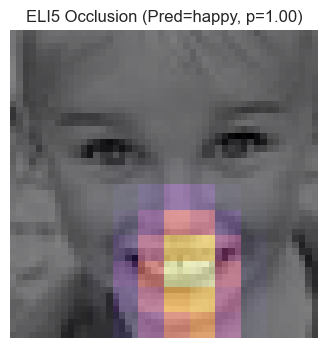

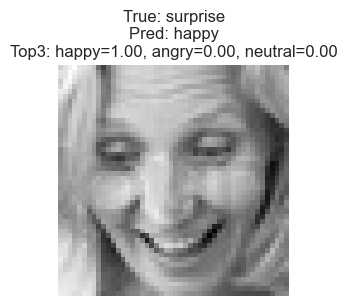

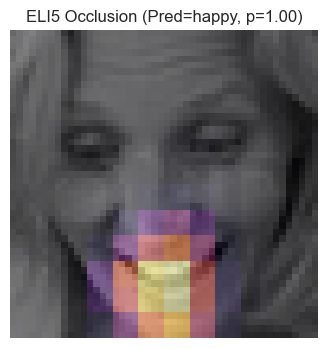

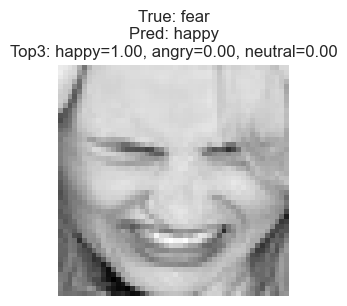

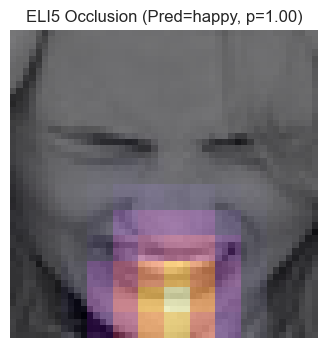

In [21]:
def occlusion_sensitivity(img, class_index, patch=8, stride=4, baseline=0.0):
    """
    Returns normalized importance heatmap: where hiding a region drops class prob most.
    """
    H, W = img.shape[0], img.shape[1]
    base_prob = final_model.predict(img[None,...], verbose=0)[0, class_index]

    heat = np.zeros((H, W), dtype=np.float32)
    cnt  = np.zeros((H, W), dtype=np.float32)

    for y in range(0, H - patch + 1, stride):
        for x in range(0, W - patch + 1, stride):
            occluded = img.copy()
            occluded[y:y+patch, x:x+patch, :] = baseline
            p = final_model.predict(occluded[None,...], verbose=0)[0, class_index]
            drop = base_prob - p  # >0 means important region
            heat[y:y+patch, x:x+patch] += drop
            cnt[y:y+patch, x:x+patch] += 1

    heat = heat / np.maximum(cnt, 1)
    heat = np.maximum(heat, 0)
    heat = heat / (heat.max() + 1e-8)
    return heat, float(base_prob)

def show_occlusion(i):
    img = X_test[i]
    pred_k = y_pred_full[i]
    heat, base_p = occlusion_sensitivity(img, pred_k, patch=8, stride=4, baseline=0.0)

    plt.figure(figsize=(4,4))
    plt.imshow(img.squeeze(), cmap="gray")
    plt.imshow(heat, cmap="inferno", alpha=0.5)
    plt.axis("off")
    plt.title(f"ELI5 Occlusion (Pred={USED_CLASSES[pred_k]}, p={base_p:.2f})")
    plt.show()

print("=== ELI5/Occlusion for 3 Misclassified ===")
for i in top_mis:
    show_image_info(i)
    show_occlusion(i)


In [22]:
def focus_region_from_heatmap(heatmap):
    y, x = np.unravel_index(np.argmax(heatmap), heatmap.shape)
    H, W = heatmap.shape
    if y < H/3:
        v = "upper face (forehead/eyes)"
    elif y < 2*H/3:
        v = "mid face (nose/cheeks)"
    else:
        v = "lower face (mouth/jaw)"
    if x < W/4 or x > 3*W/4:
        h = "edge/side"
    else:
        h = "center"
    return v, h

def write_analysis_for_misclassified(i):
    img = X_test[i]
    true_k = y_true_full[i]
    pred_k = y_pred_full[i]

    # Grad-CAM on predicted class
    hm = make_gradcam_heatmap(img, final_model, LAST_CONV, class_index=pred_k)
    v, h = focus_region_from_heatmap(hm)

    top3 = np.argsort(-proba_full[i])[:3]
    top3_txt = ", ".join([f"{USED_CLASSES[k]}={proba_full[i,k]:.2f}" for k in top3])

    print("--------------------------------------------------")
    print(f"Image #{i}")
    print(f"True label      : {USED_CLASSES[true_k]}")
    print(f"Predicted label : {USED_CLASSES[pred_k]}")
    print(f"Top-3 probs     : {top3_txt}")
    print(f"Grad-CAM focus  : {v}, mostly {h}")

    print("\nWhy likely misclassified?")
    print("- Emotions like fear/surprise or sad/neutral are visually similar in 48×48 grayscale.")
    print("- Grad-CAM suggests the model emphasized a limited region; if that region is ambiguous (e.g., eyes only), it can confuse classes.")
    print("- Possible dataset issues: label noise, occlusion, low contrast, head pose.")

    print("\nWhat to improve in training?")
    print("- Increase input resolution (e.g., 96×96) or use a slightly deeper CNN with residual blocks.")
    print("- Handle class imbalance: class weights or focal loss; inspect per-class precision/recall.")
    print("- Add augmentation targeted to faces: random brightness/contrast, slight blur, random crop.")
    print("- Face alignment / cropping around landmarks (eyes-mouth) can reduce background bias.")
    print("- Try temperature scaling for calibration; reduce overconfident mistakes.")
    print("--------------------------------------------------\n")

print("=== Written Analysis for 3 Misclassified ===")
for i in top_mis:
    write_analysis_for_misclassified(i)


=== Written Analysis for 3 Misclassified ===
--------------------------------------------------
Image #6631
True label      : surprise
Predicted label : happy
Top-3 probs     : happy=1.00, neutral=0.00, angry=0.00
Grad-CAM focus  : lower face (mouth/jaw), mostly center

Why likely misclassified?
- Emotions like fear/surprise or sad/neutral are visually similar in 48×48 grayscale.
- Grad-CAM suggests the model emphasized a limited region; if that region is ambiguous (e.g., eyes only), it can confuse classes.
- Possible dataset issues: label noise, occlusion, low contrast, head pose.

What to improve in training?
- Increase input resolution (e.g., 96×96) or use a slightly deeper CNN with residual blocks.
- Handle class imbalance: class weights or focal loss; inspect per-class precision/recall.
- Add augmentation targeted to faces: random brightness/contrast, slight blur, random crop.
- Face alignment / cropping around landmarks (eyes-mouth) can reduce background bias.
- Try temperature s